# Figures 2 — version harmonisée

Toutes les figures sont en `figsize=(8,6)`. Chaque cellule est autonome (imports + chargement des données + tracé) tout en réutilisant la même logique de couleurs (`color_list`) d'une cellule à l'autre lorsque cela a du sens physiquement.

# 2.A : Few trajectories + Mean + Theory (Homogeneous)

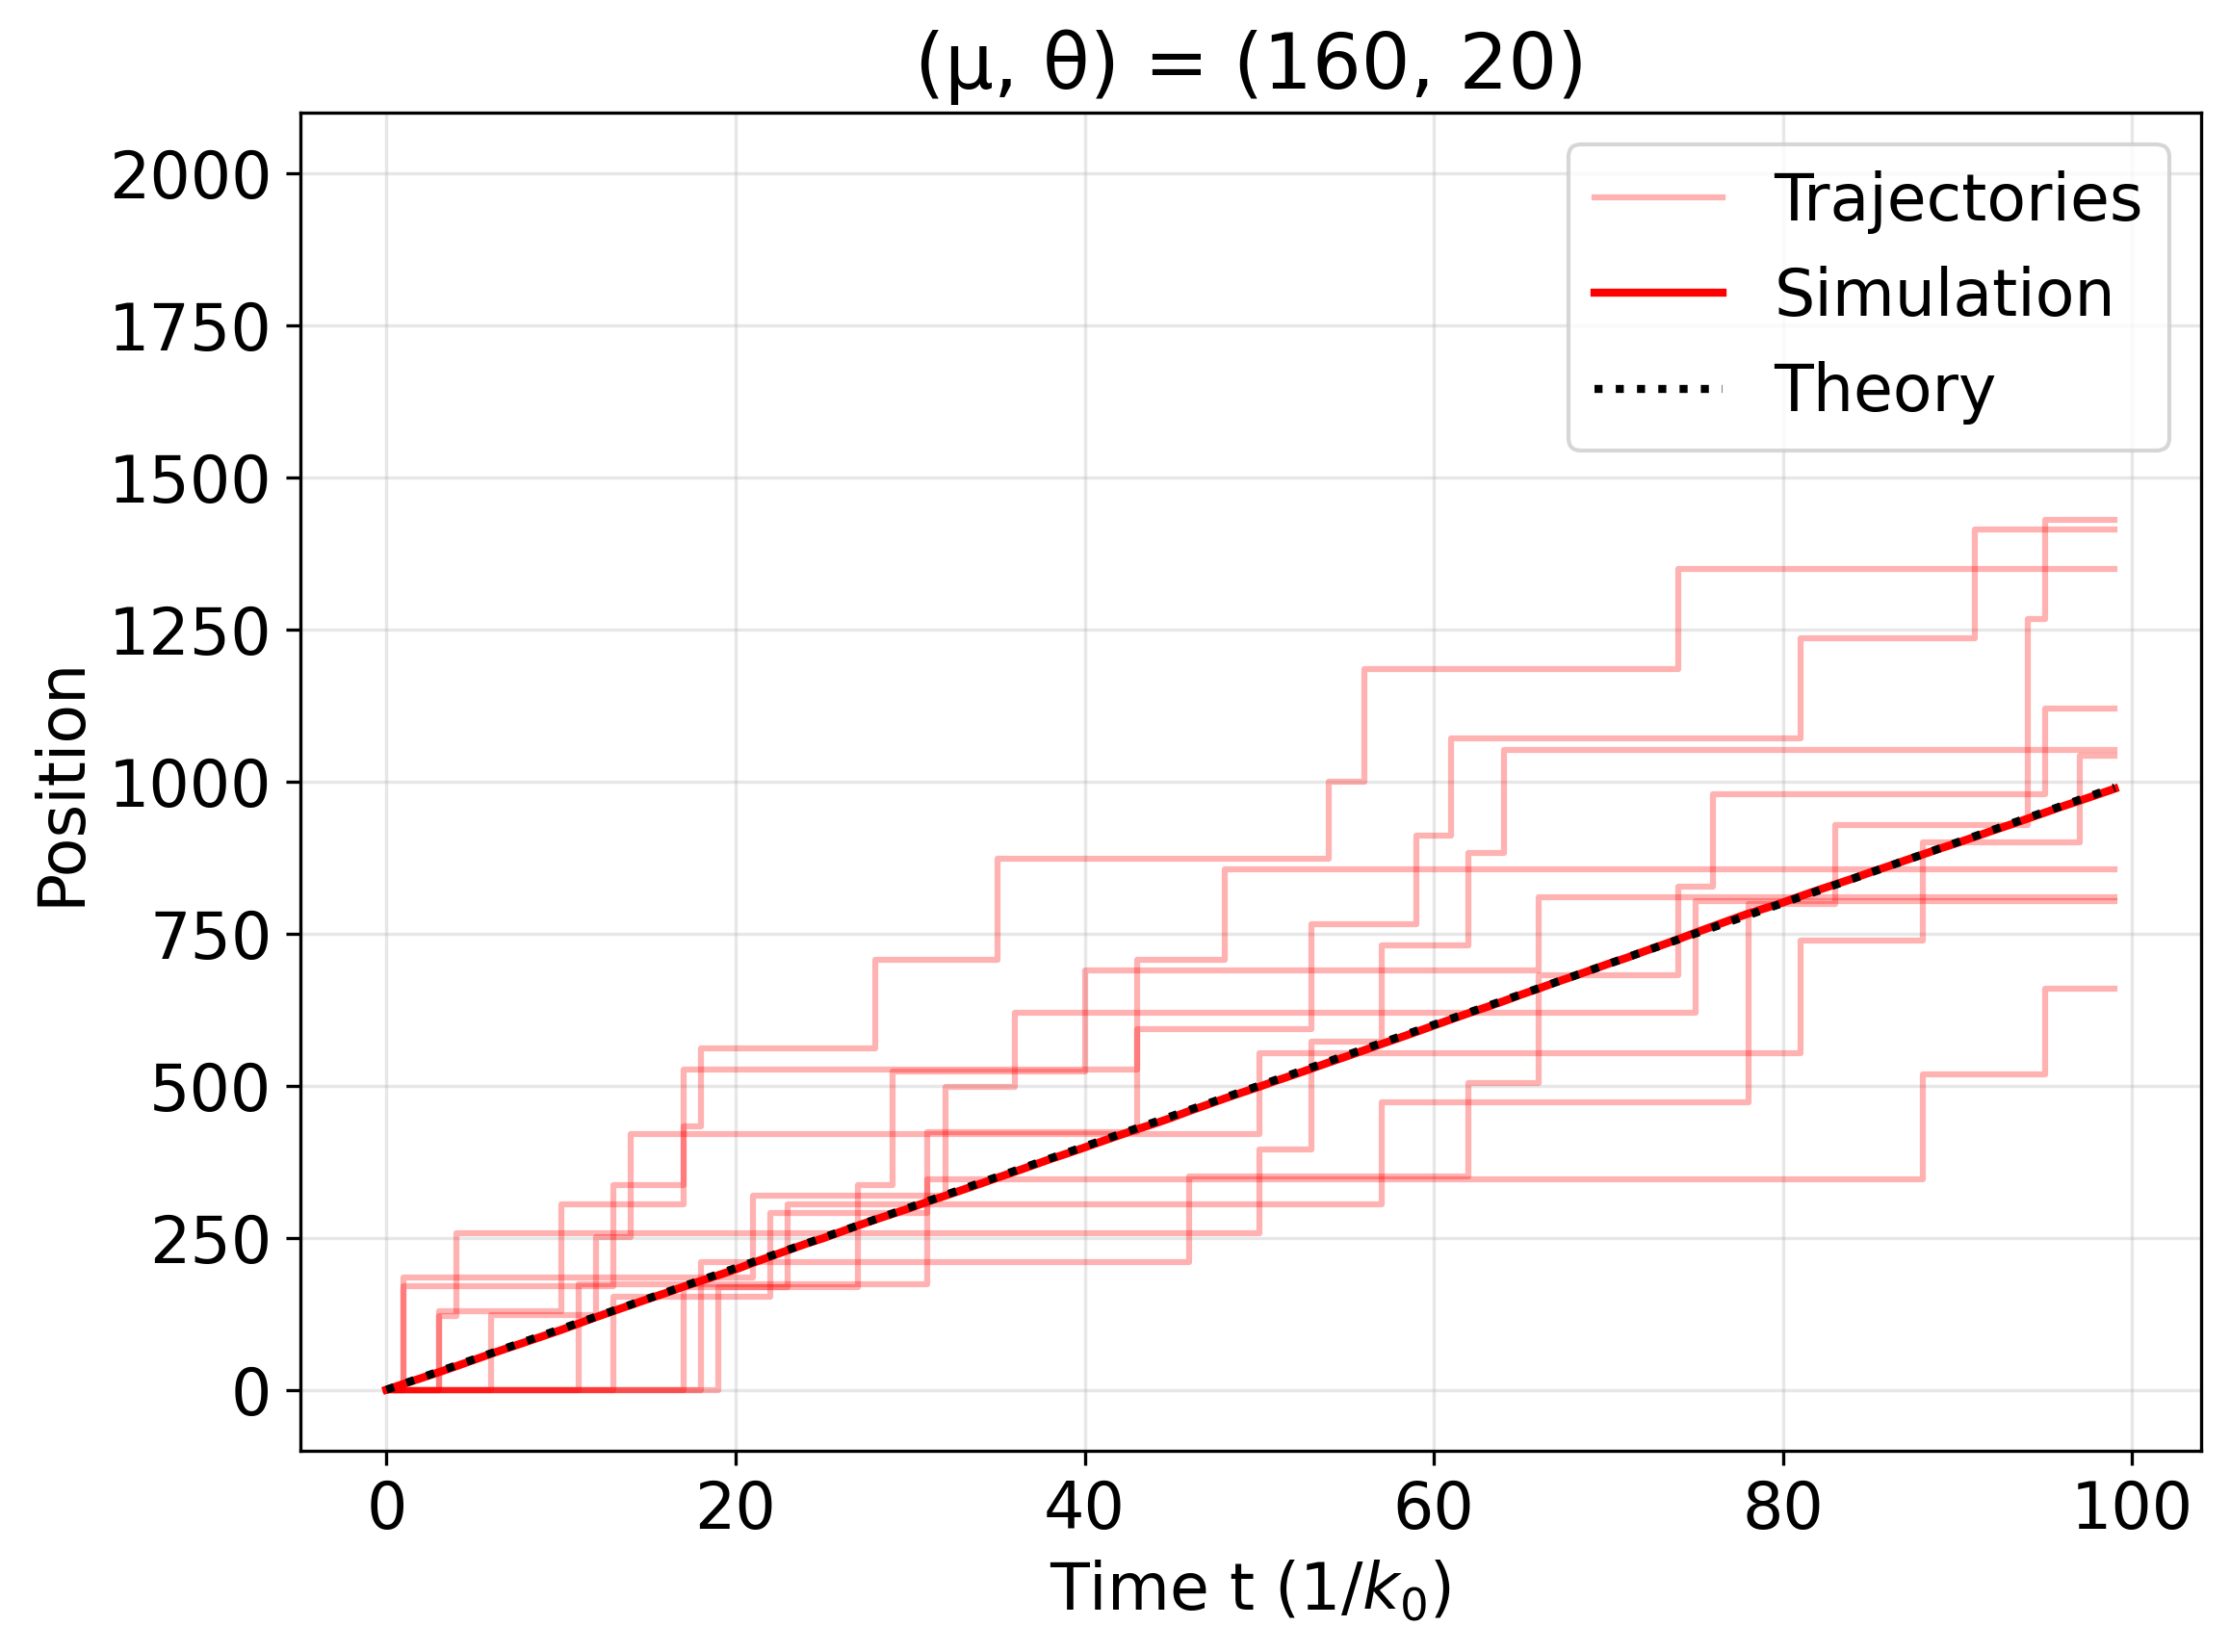

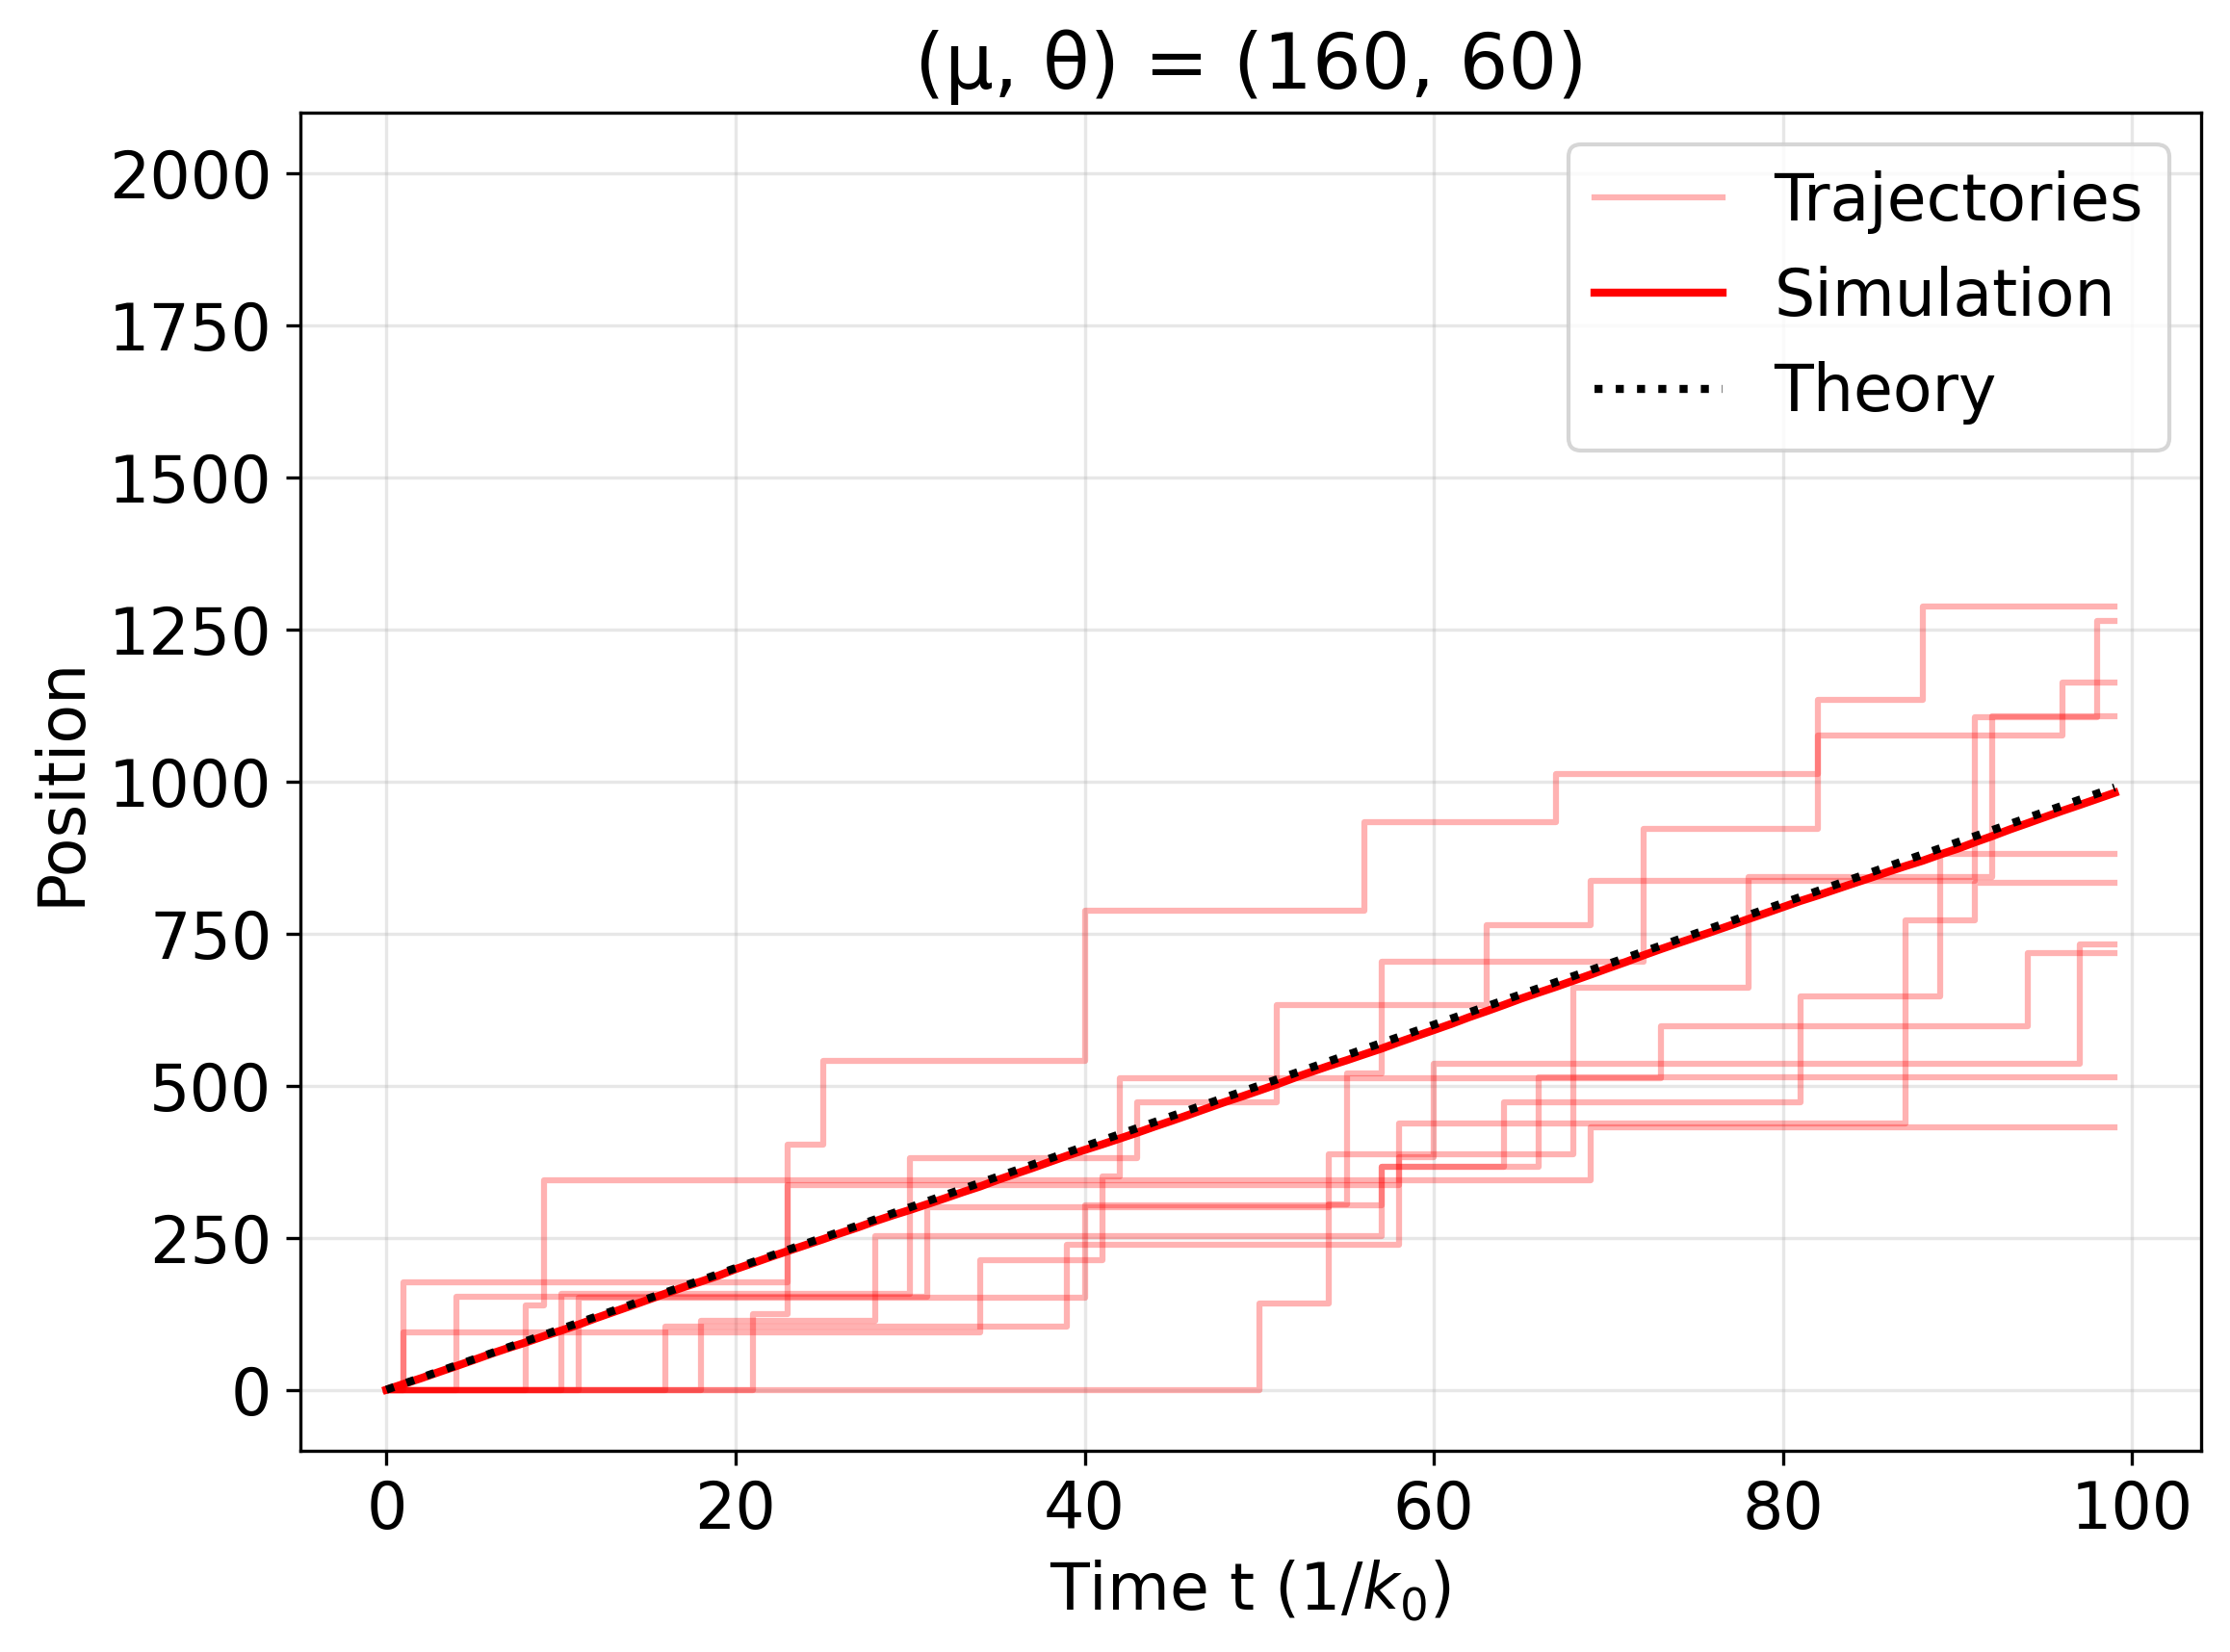

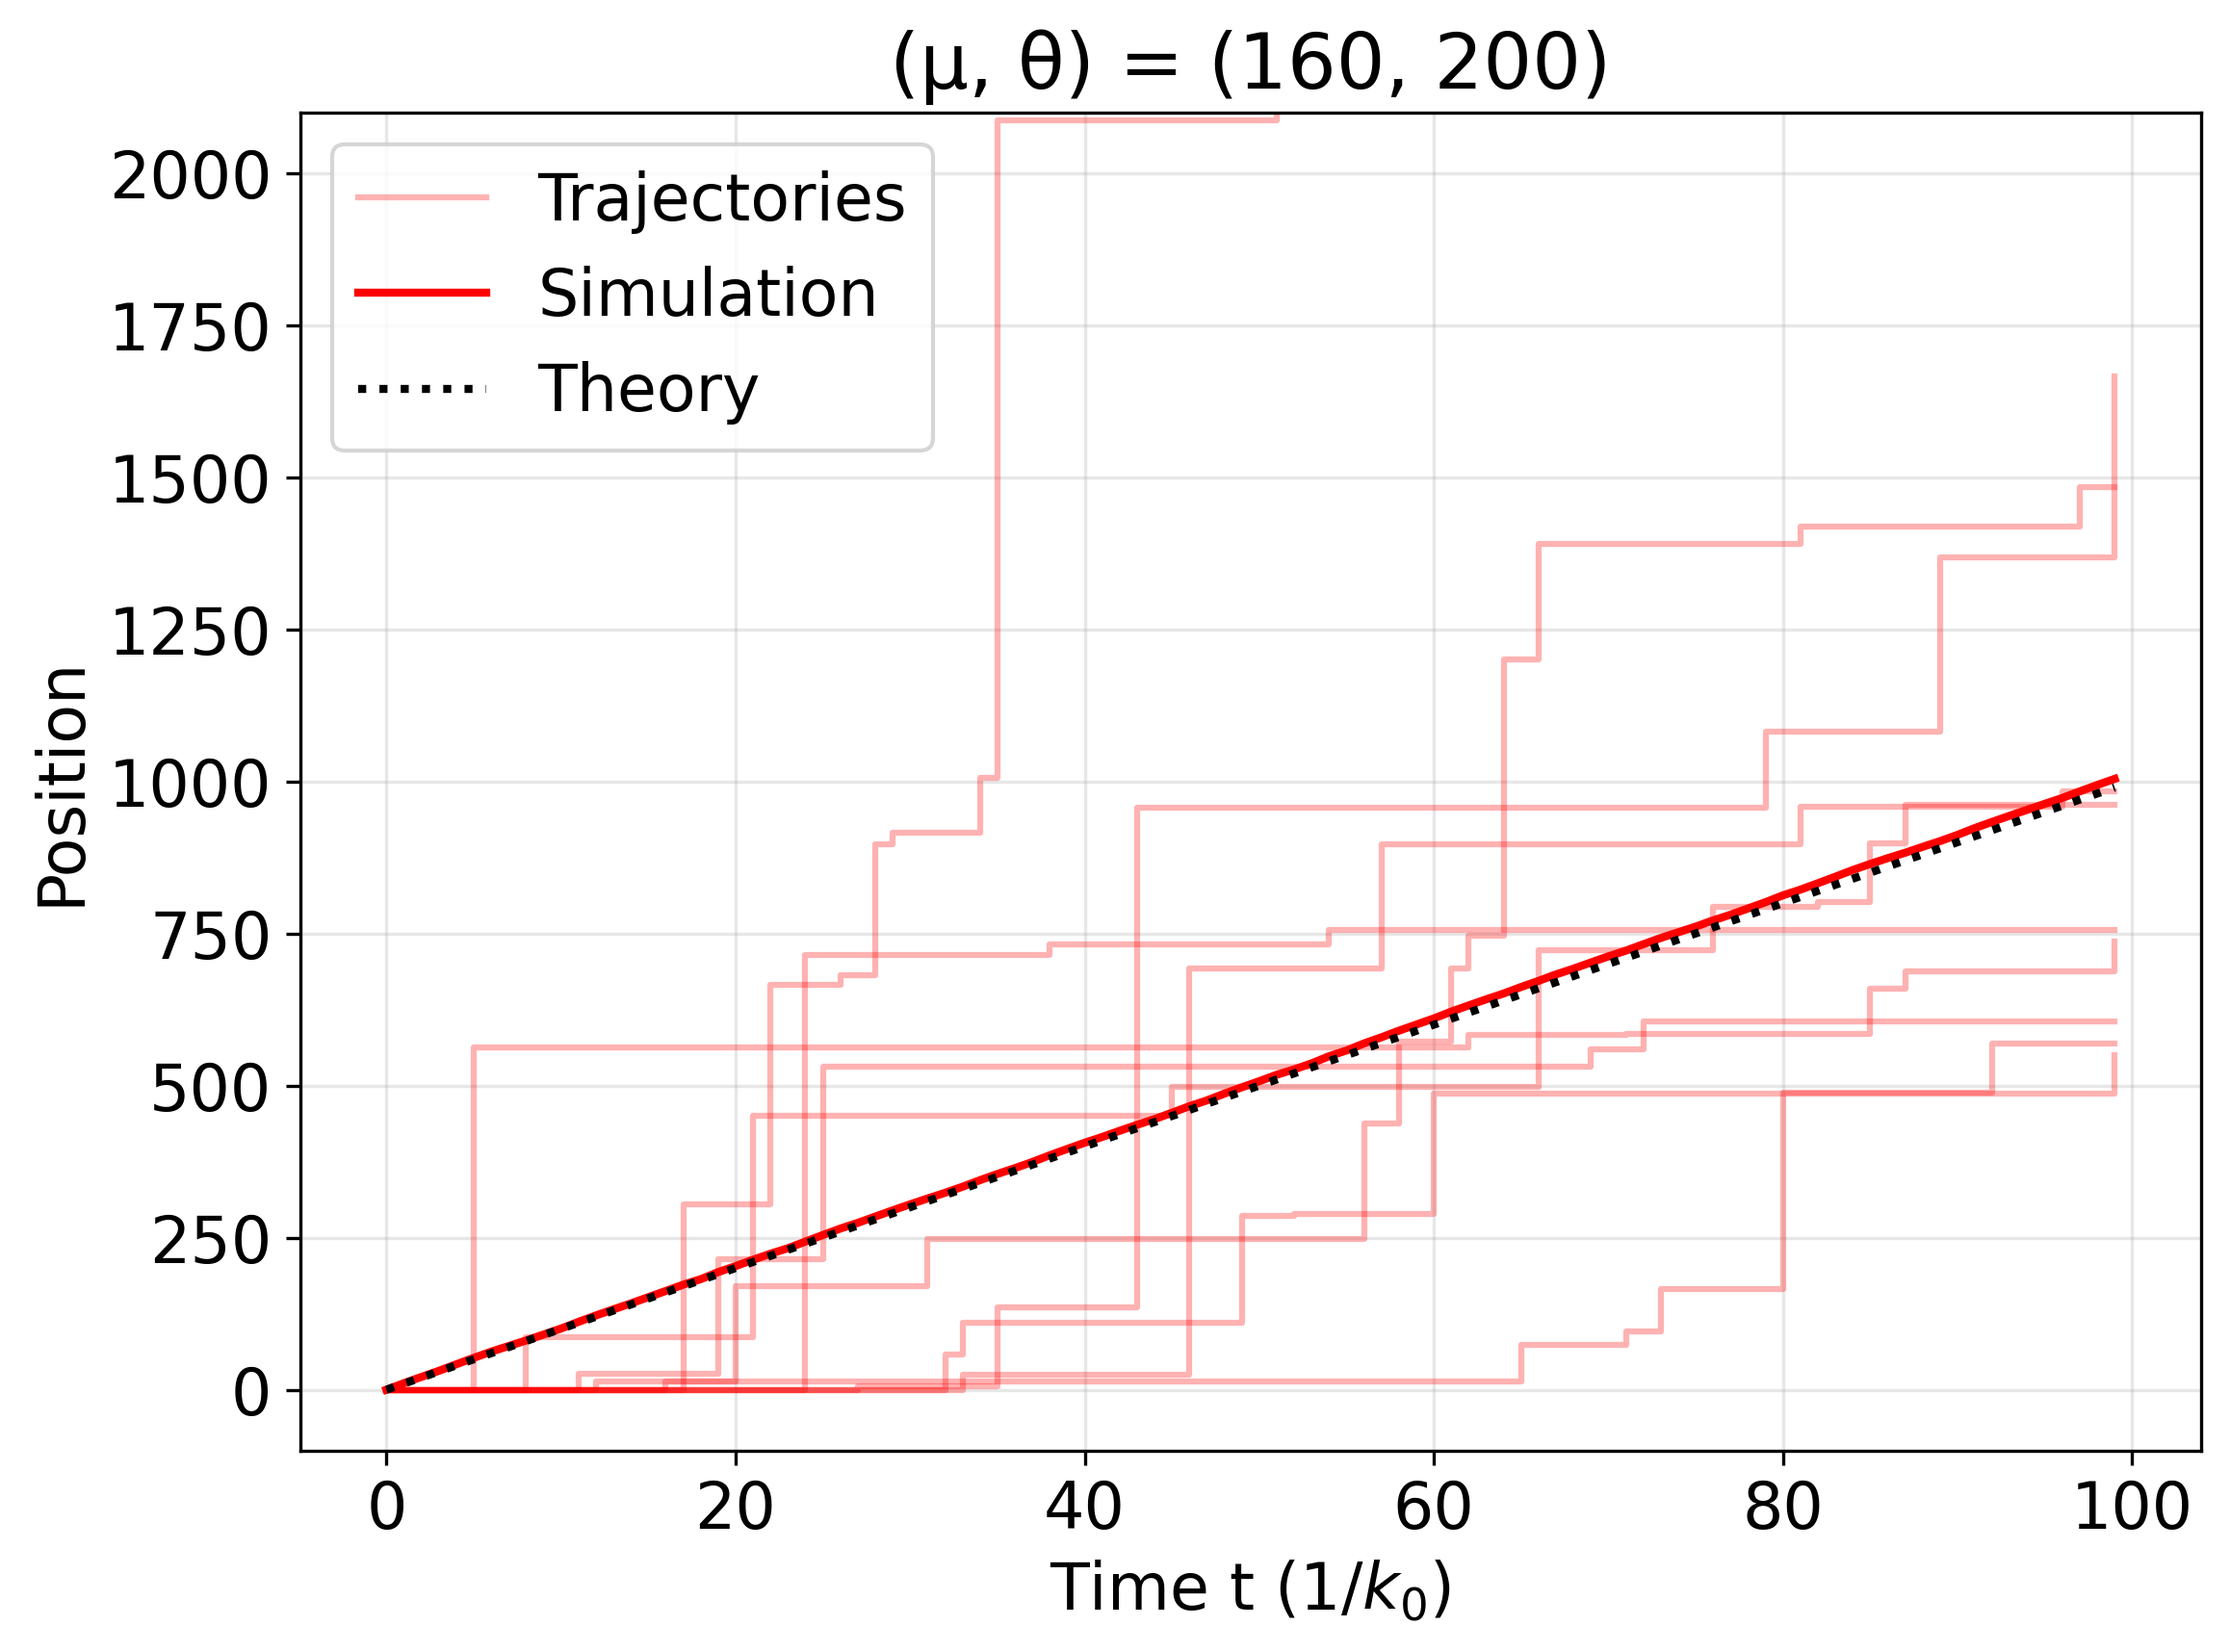

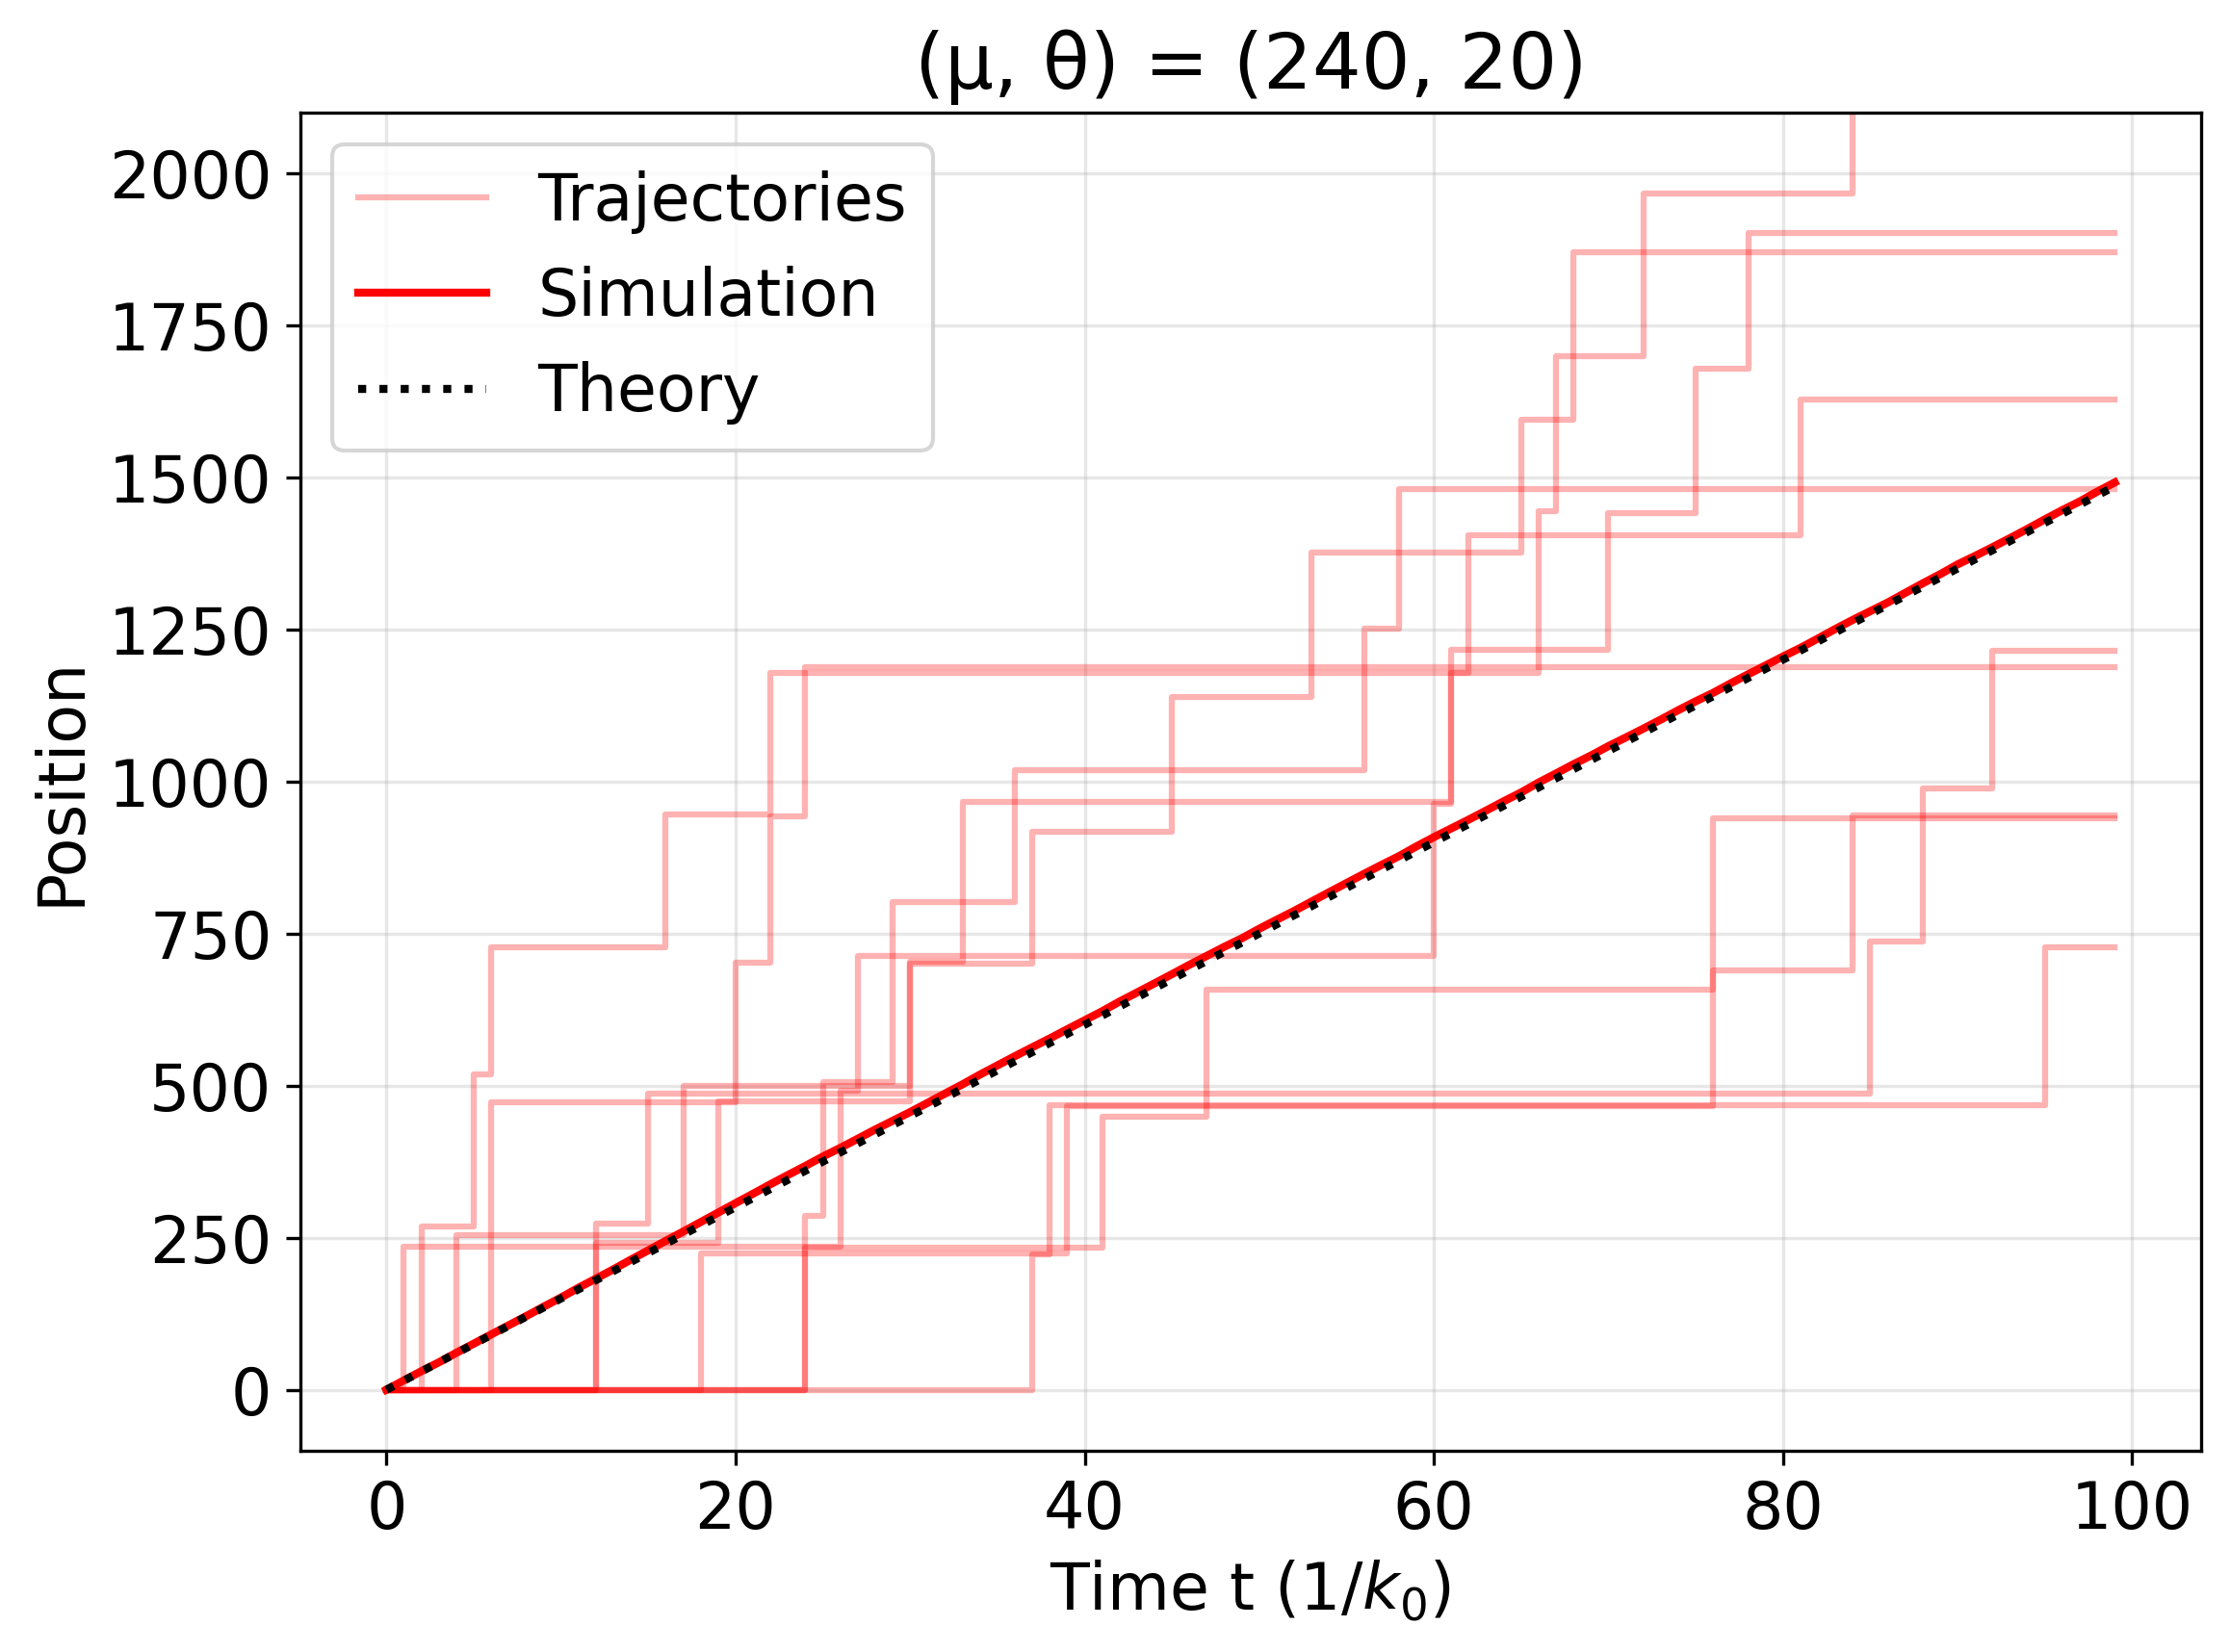

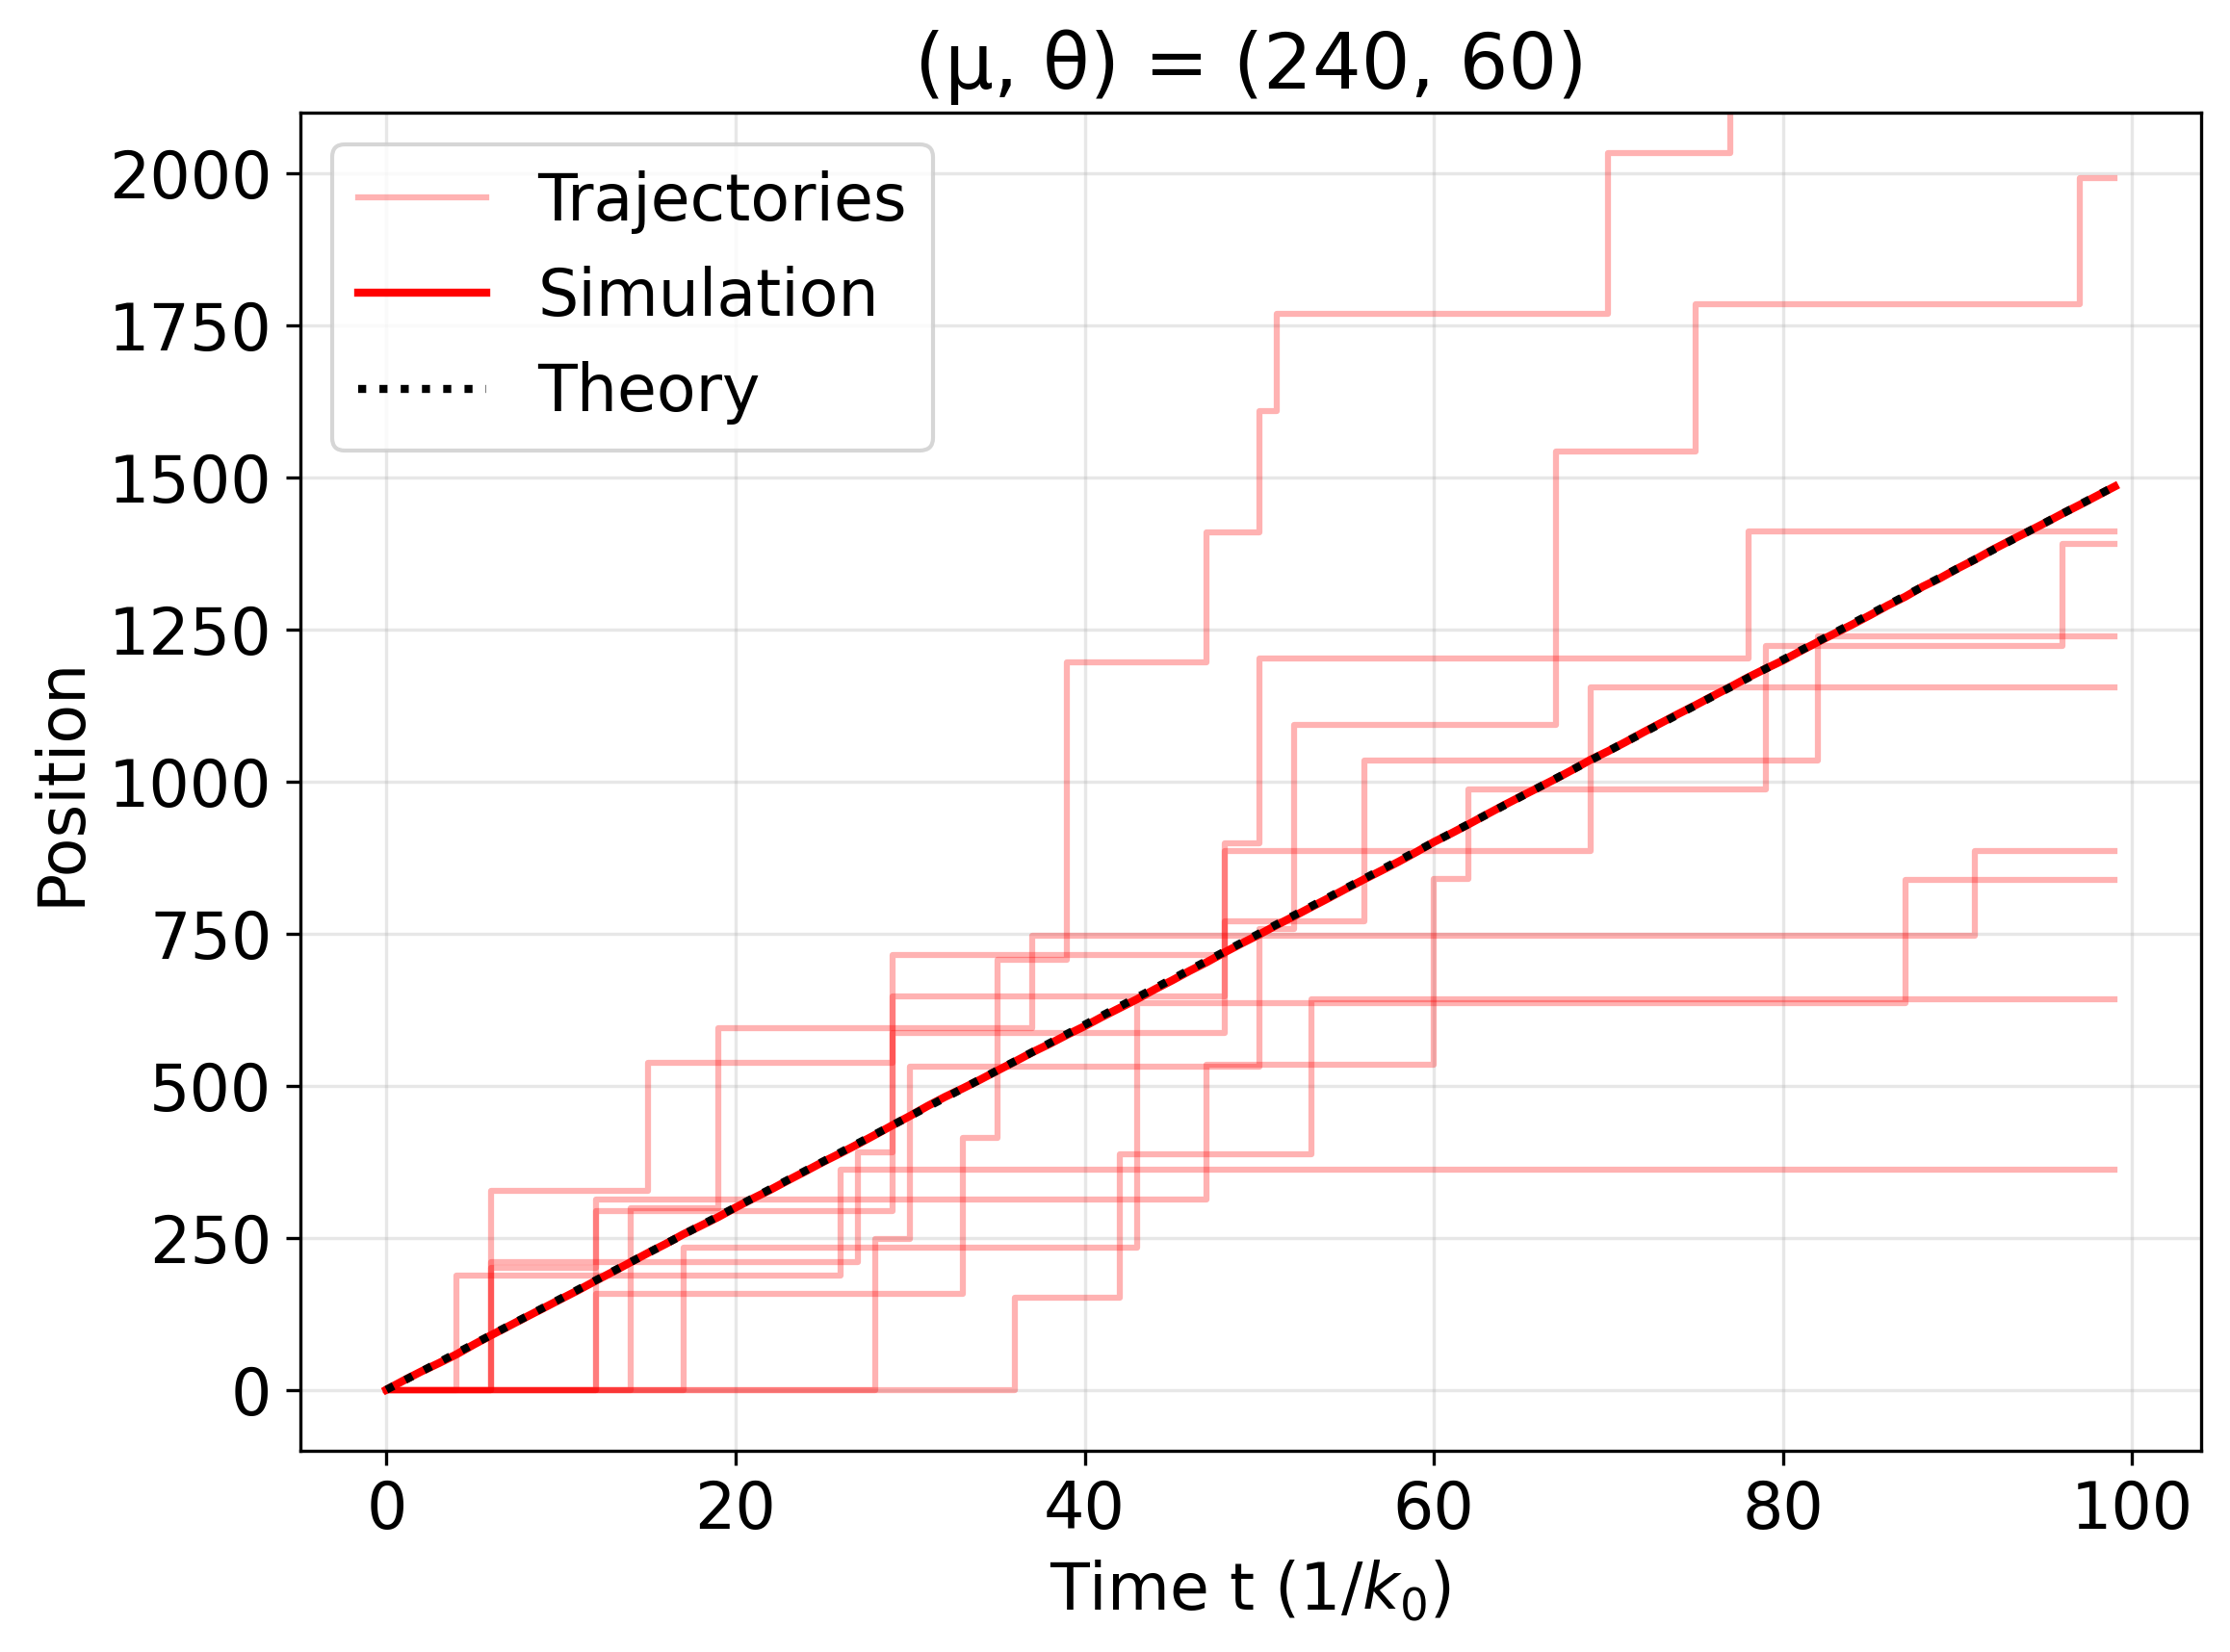

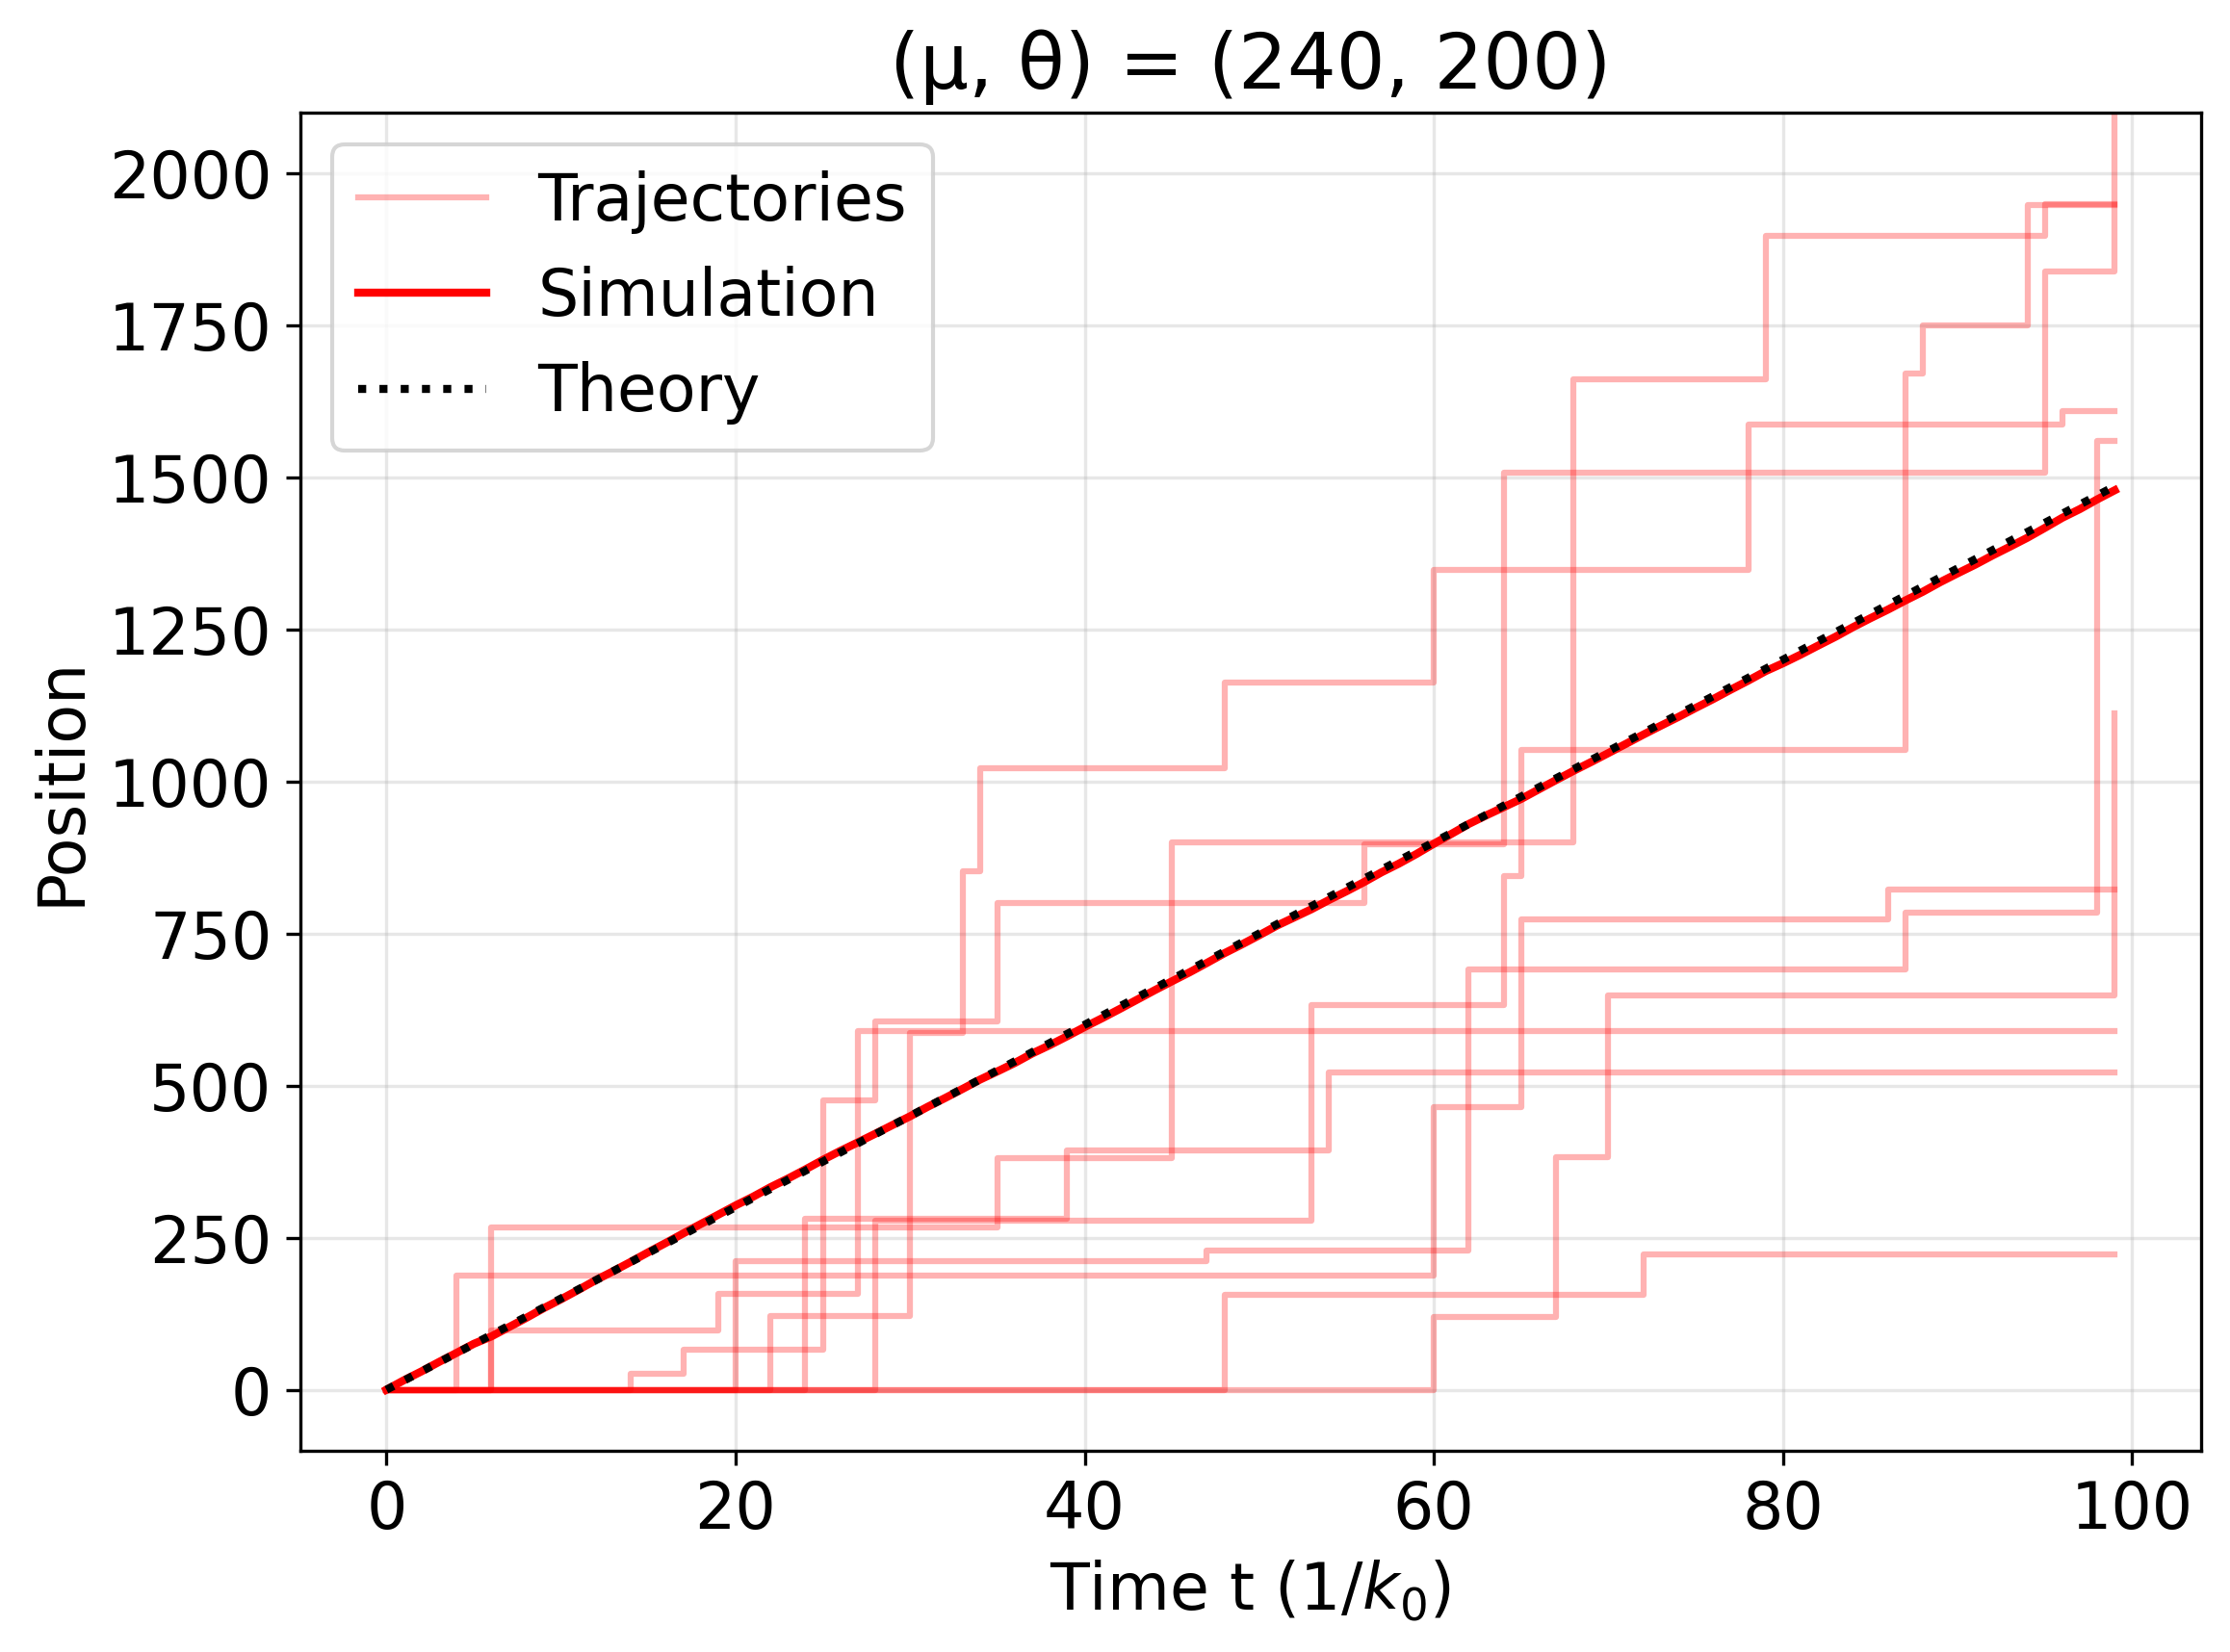

In [1]:
# ── Imports ──────────────────────────────────────────────────────────────────
from pathlib import Path
import numpy as np
import polars as pl
import matplotlib.pyplot as plt

plt.rcParams["font.size"] = 16

# ── Load files ───────────────────────────────────────────────────────────────
root = Path("/home/nicolas/Documents/Workspace/nucleo/outputs/FIGURES__PC__2026-06-18/nucleo__fig2__0")
paths = sorted(str(p) for p in root.glob("*/**/*.parquet")) or sorted(str(p) for p in root.glob("*/*.parquet"))

df_all = (
    pl.scan_parquet(paths)
    .collect()
    .sort(by=[
        "algo", "fact", "mode",
        "land", "s", "l", "alphac", "alphar"
    ])
)

df_one = df_all.filter(pl.col("land") == "homogen")

# ── Couples uniques (mu, theta) ──────────────────────────────────────────────
pairs = (
    df_one.select(["mu", "theta"])
    .unique()
    .sort(["mu", "theta"])
    .to_numpy()
)

# ── Couleurs (une couleur par couple (mu, theta), cohérent sur tout le notebook) ──
color_list = ["red"] * len(pairs)  # une seule courbe par figure -> rouge par défaut

# ── Loop & Plot ──────────────────────────────────────────────────────────────
for idx, (mu_val, theta_val) in enumerate(pairs):

    df_theta = df_one.filter(
        (pl.col("mu") == mu_val) &
        (pl.col("theta") == theta_val)
    )

    if df_theta.height == 0:
        continue

    # --- SAFE extraction --- #
    trajs = df_theta["results"][0]          # déjà une list/array
    mean_traj = df_theta["results_mean"][0]
    times = df_theta["times"][0]
    v_mean_th = df_theta["v_mean_th"][0]

    # mu peut être scalar ou array selon ton dataset
    mu = df_theta["mu"][0]

    color = color_list[idx]

    # --- Plot --- #
    plt.figure(figsize=(8, 6), dpi=300)

    # trajectoires
    n_traj = min(10, len(trajs))
    for i in range(n_traj):
        plt.plot(trajs[i], drawstyle="steps-post",
                 color=color, alpha=0.3,
                 label="Trajectories" if i == 0 else None)

    # moyenne
    plt.plot(mean_traj,
             color=color, lw=2,
             label="Simulation")

    # théorie (IMPORTANT: scalaire attendu)
    plt.plot(times, np.array(times) * v_mean_th,
             color="black", lw=2, ls=":",
             label="Theory")

    plt.ylim([-100, 2100])
    plt.grid(alpha=0.3)
    plt.title(f"(μ, θ) = ({mu}, {theta_val})")
    plt.xlabel(r"Time t ($1/k_0$)")
    plt.ylabel("Position")
    plt.legend()
    plt.tight_layout()
    plt.show()


# 2.B : Their distributions of speeds

/tmp/ipykernel_10846/4153648717.py:34: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap("viridis")


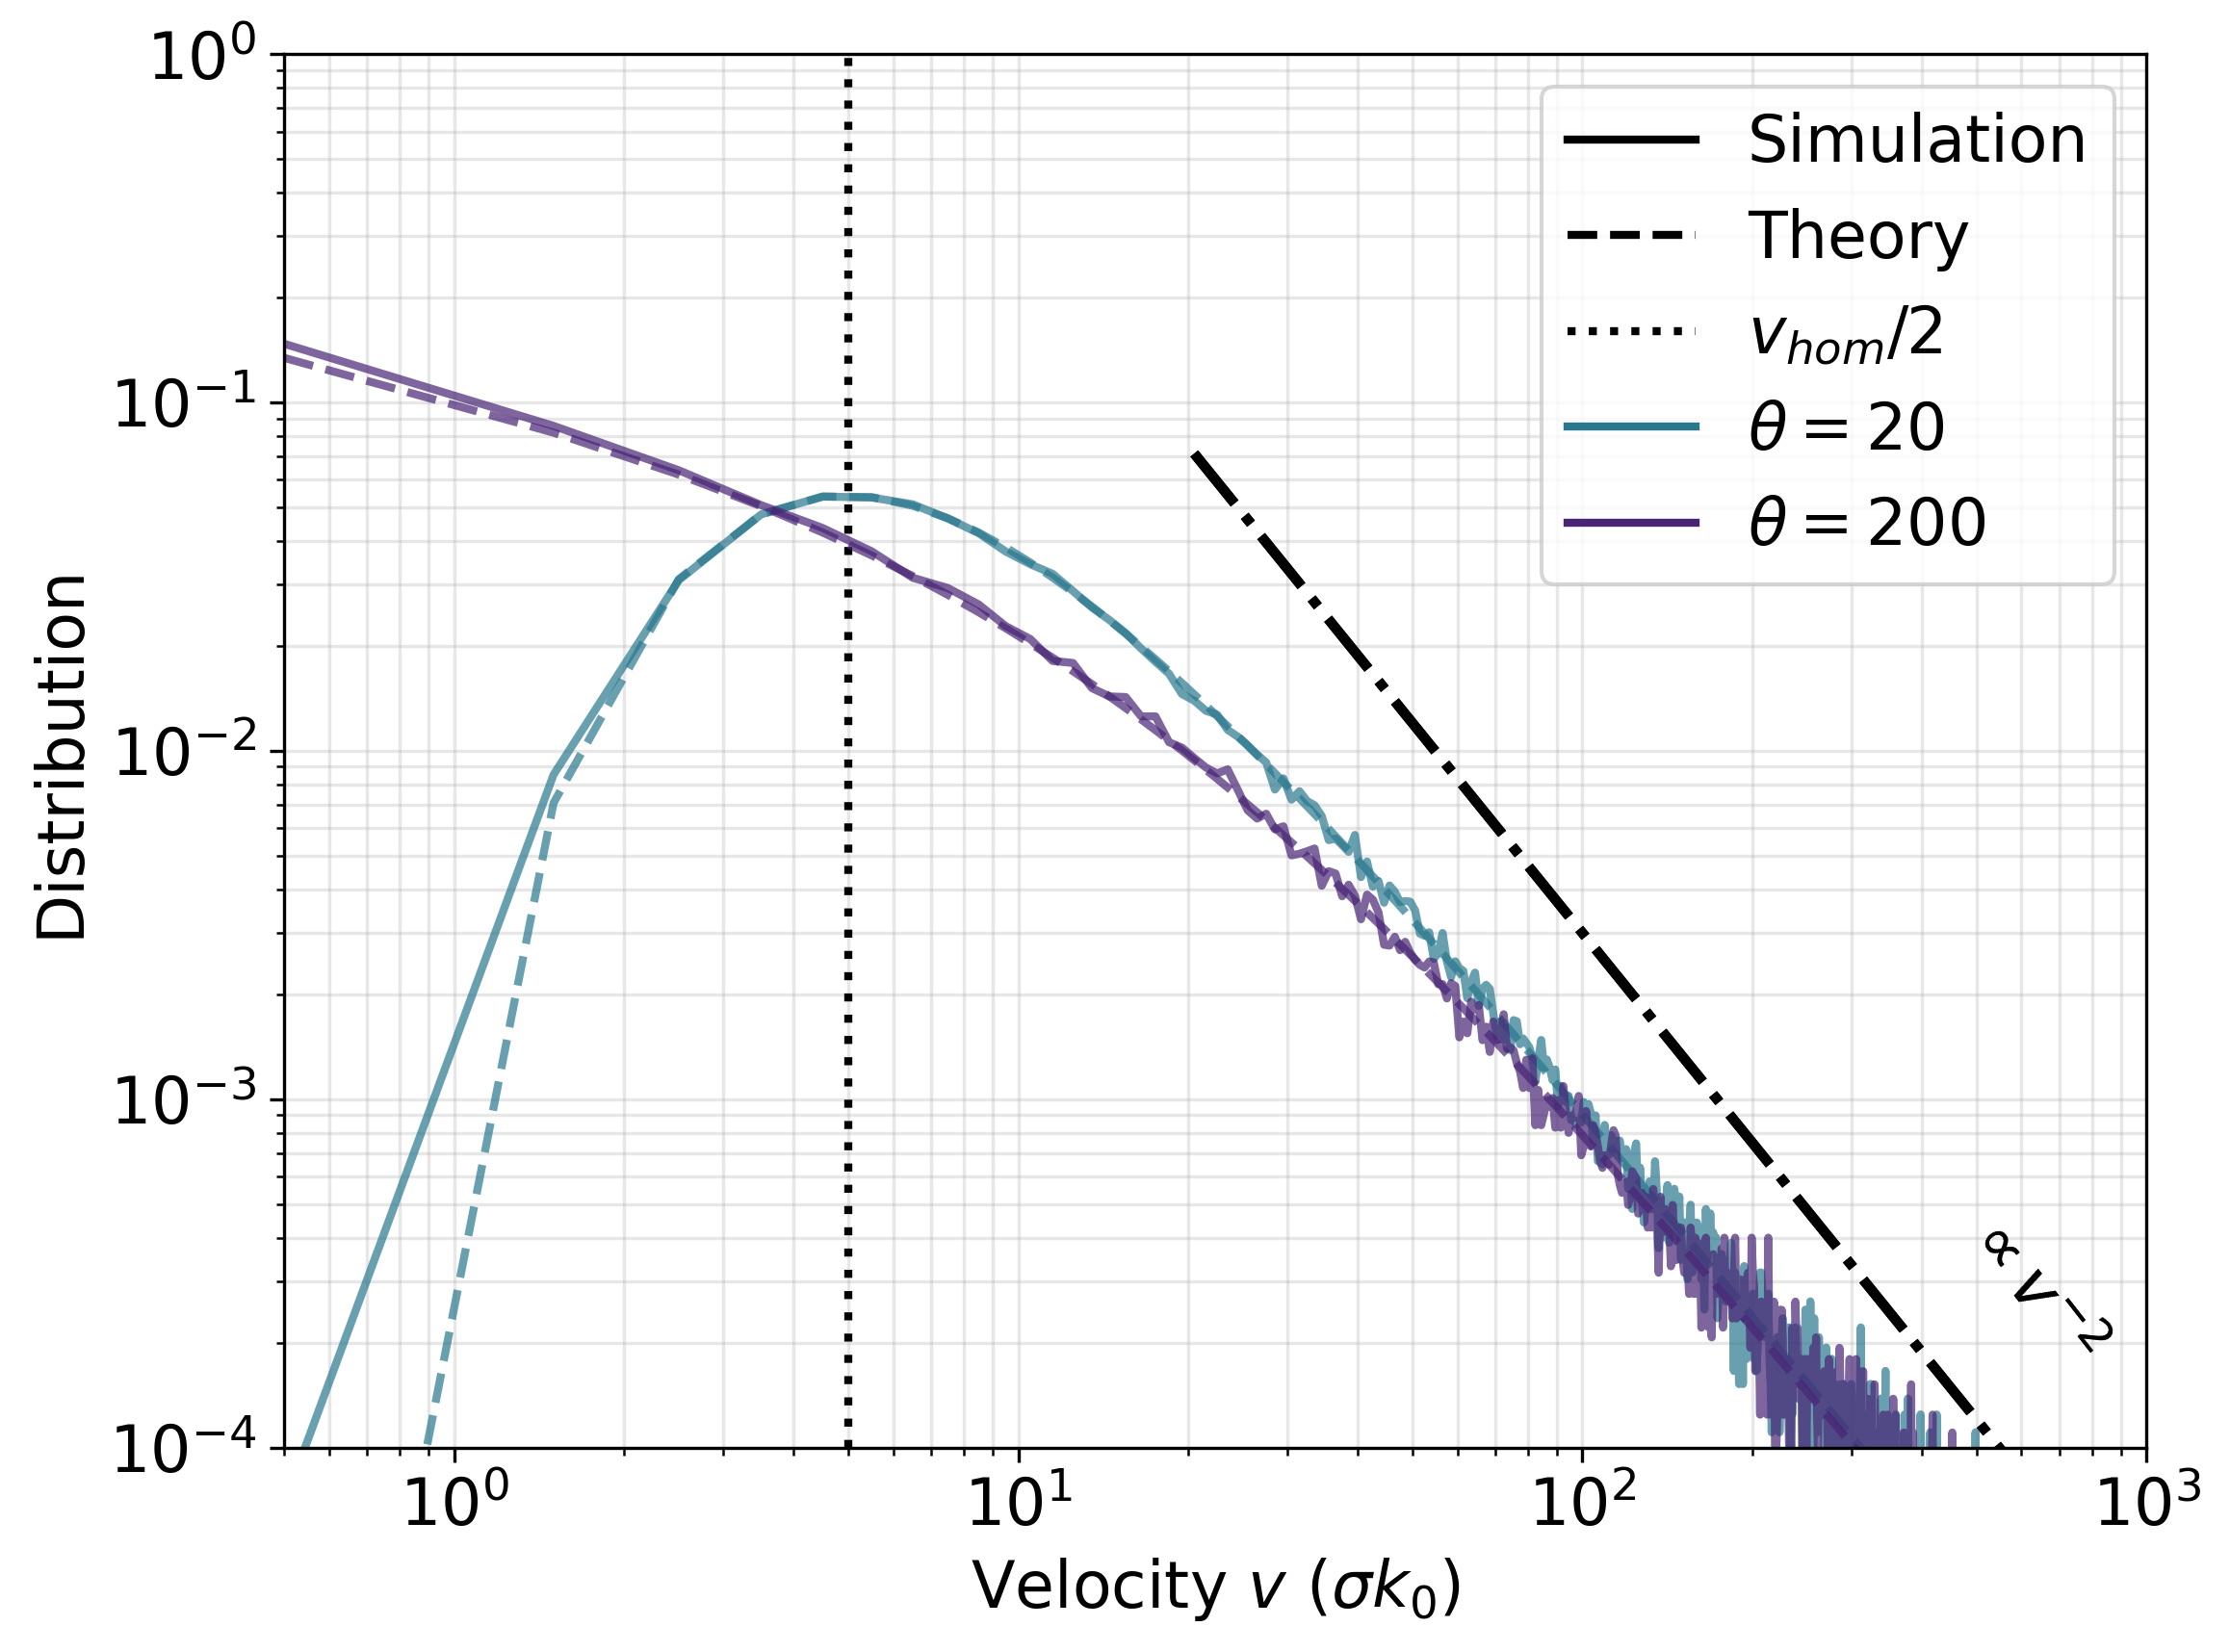

In [2]:
# ── Imports ──────────────────────────────────────────────────────────────────
from pathlib import Path
import numpy as np
import polars as pl
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from matplotlib.lines import Line2D

plt.rcParams["font.size"] = 16

# ── Load files ───────────────────────────────────────────────────────────────
root = Path("/home/nicolas/Documents/Workspace/nucleo/outputs/FIGURES__PC__2026-06-18/nucleo__fig2__0")
paths = sorted(str(p) for p in root.glob("*/**/*.parquet")) or sorted(str(p) for p in root.glob("*/*.parquet"))

df_all = (
    pl.scan_parquet(paths)
    .collect()
    .sort(by=[
        "algo", "fact", "mode",
        "land", "s", "l", "alphac", "alphar"
    ])
)

# ── Theta values étudiés ─────────────────────────────────────────────────────
thetas = np.array([20, 200])

# ── Théorie : distribution instantanée des vitesses ─────────────────────────
def th_instantaneous_speeds(mu, theta, v, alpha0=10/160, k0=1):
    a = (mu / theta) ** 2
    b = mu / (theta ** 2)
    return (alpha0 * k0) * (a*b) * (v*b)**(a-1) / (alpha0*k0 + b*v)**(a+1)

# ── Couleurs (une couleur par theta) ─────────────────────────────────────────
cmap = cm.get_cmap("viridis")
n_colors = len(thetas)
color_positions = np.linspace(0.1, 0.4, n_colors)  # ajuste l'intervalle si besoin
color_list = [cmap(pos) for pos in color_positions]
color_list.reverse()

# ── Figure ───────────────────────────────────────────────────────────────────
plt.figure(figsize=(8, 6), dpi=300)

# v_mean (ligne verticale, sans label)
MU = df_all["mu"].to_numpy()
l = df_all["l"].to_numpy()
s = df_all["s"].to_numpy()
alpha = l[0] / (l[0] + s[0])

plt.axvline(
    x=alpha * MU[0] / 2,
    color="black",
    ls=":",
    lw=2,
    alpha=1,
    label="_nolegend_"
)

for idx, theta_val in enumerate(thetas[0:3]):

    df_theta = df_all.filter(pl.col("theta") == theta_val)
    mu = df_theta["mu"][0]
    vi_points = df_theta["vi_points"][0].to_numpy()
    vi_distrib = df_theta["vi_distrib"][0].to_numpy()
    v_mean = df_theta["v_mean"].to_numpy()

    # =========================
    #  Ligne théorie v_init ~ alpha * (sigma k0)^-2
    # =========================
    alpha_th = 1  # ajuste si nécessaire pour que la courbe tombe au bon niveau
    init_points = vi_points[int(len(vi_points)/5000):]
    v_init = alpha_th * init_points**(-2)

    plt.plot(
        init_points,
        v_init * 30,
        color="black",
        ls="dashdot",
        lw=2.5,
        label=r"$\propto v_{i}^{-2}$"
    )

    ax = plt.gca()
    ax.text(
        0.98, 0.05,                         # (x,y) en coordonnées d'axe
        r"$\propto v^{-2}$",
        transform=ax.transAxes,
        fontsize=16,
        color="black",
        ha="right",
        va="bottom",
        rotation=-52
    )

    # Simulation (avec label couleur)
    plt.plot(
        vi_points,
        vi_distrib,
        color=color_list[idx],
        ls="-",
        lw=2,
        alpha=0.70,
        label=f"(μ,θ)=({mu},{theta_val})"
    )

    # Théorie (sans label)
    plt.plot(
        vi_points,
        th_instantaneous_speeds(mu, theta_val, vi_points),
        color=color_list[idx],
        ls="--",
        lw=2,
        alpha=0.70,
        label="_nolegend_"
    )

# ── Légendes ─────────────────────────────────────────────────────────────────
ax = plt.gca()

style_legend = [
    Line2D([0], [0], color="black", lw=2, ls="-", label="Simulation"),
    Line2D([0], [0], color="black", lw=2, ls="--", label="Theory"),
    Line2D([0], [0], color="black", lw=2, ls=":", label=r"$v_{hom}/2$")
]

theta_labels = [r"$\theta={}$".format(t) for t in thetas]
color_legend = [Line2D([0], [0], color=color_list[i], lw=2, label=theta_labels[i])
                for i in range(len(thetas))]

all_legend = style_legend + color_legend
ax.legend(handles=all_legend, loc="upper right", frameon=True)  # pas de ncol = vertical

plt.xlabel(r'Velocity $v$ ($\sigma k_0$)')
plt.ylabel("Distribution")
plt.xlim([5e-1, 1e3])
plt.ylim([1e-4, 1e0])
plt.xscale("log")
plt.yscale("log")
plt.grid(True, alpha=0.3, which="both")

plt.tight_layout()
plt.show()


# 2.D : Distributions de vitesses pour plusieurs $(\mu, \theta)$

/tmp/ipykernel_8390/1983015973.py:32: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap("plasma")


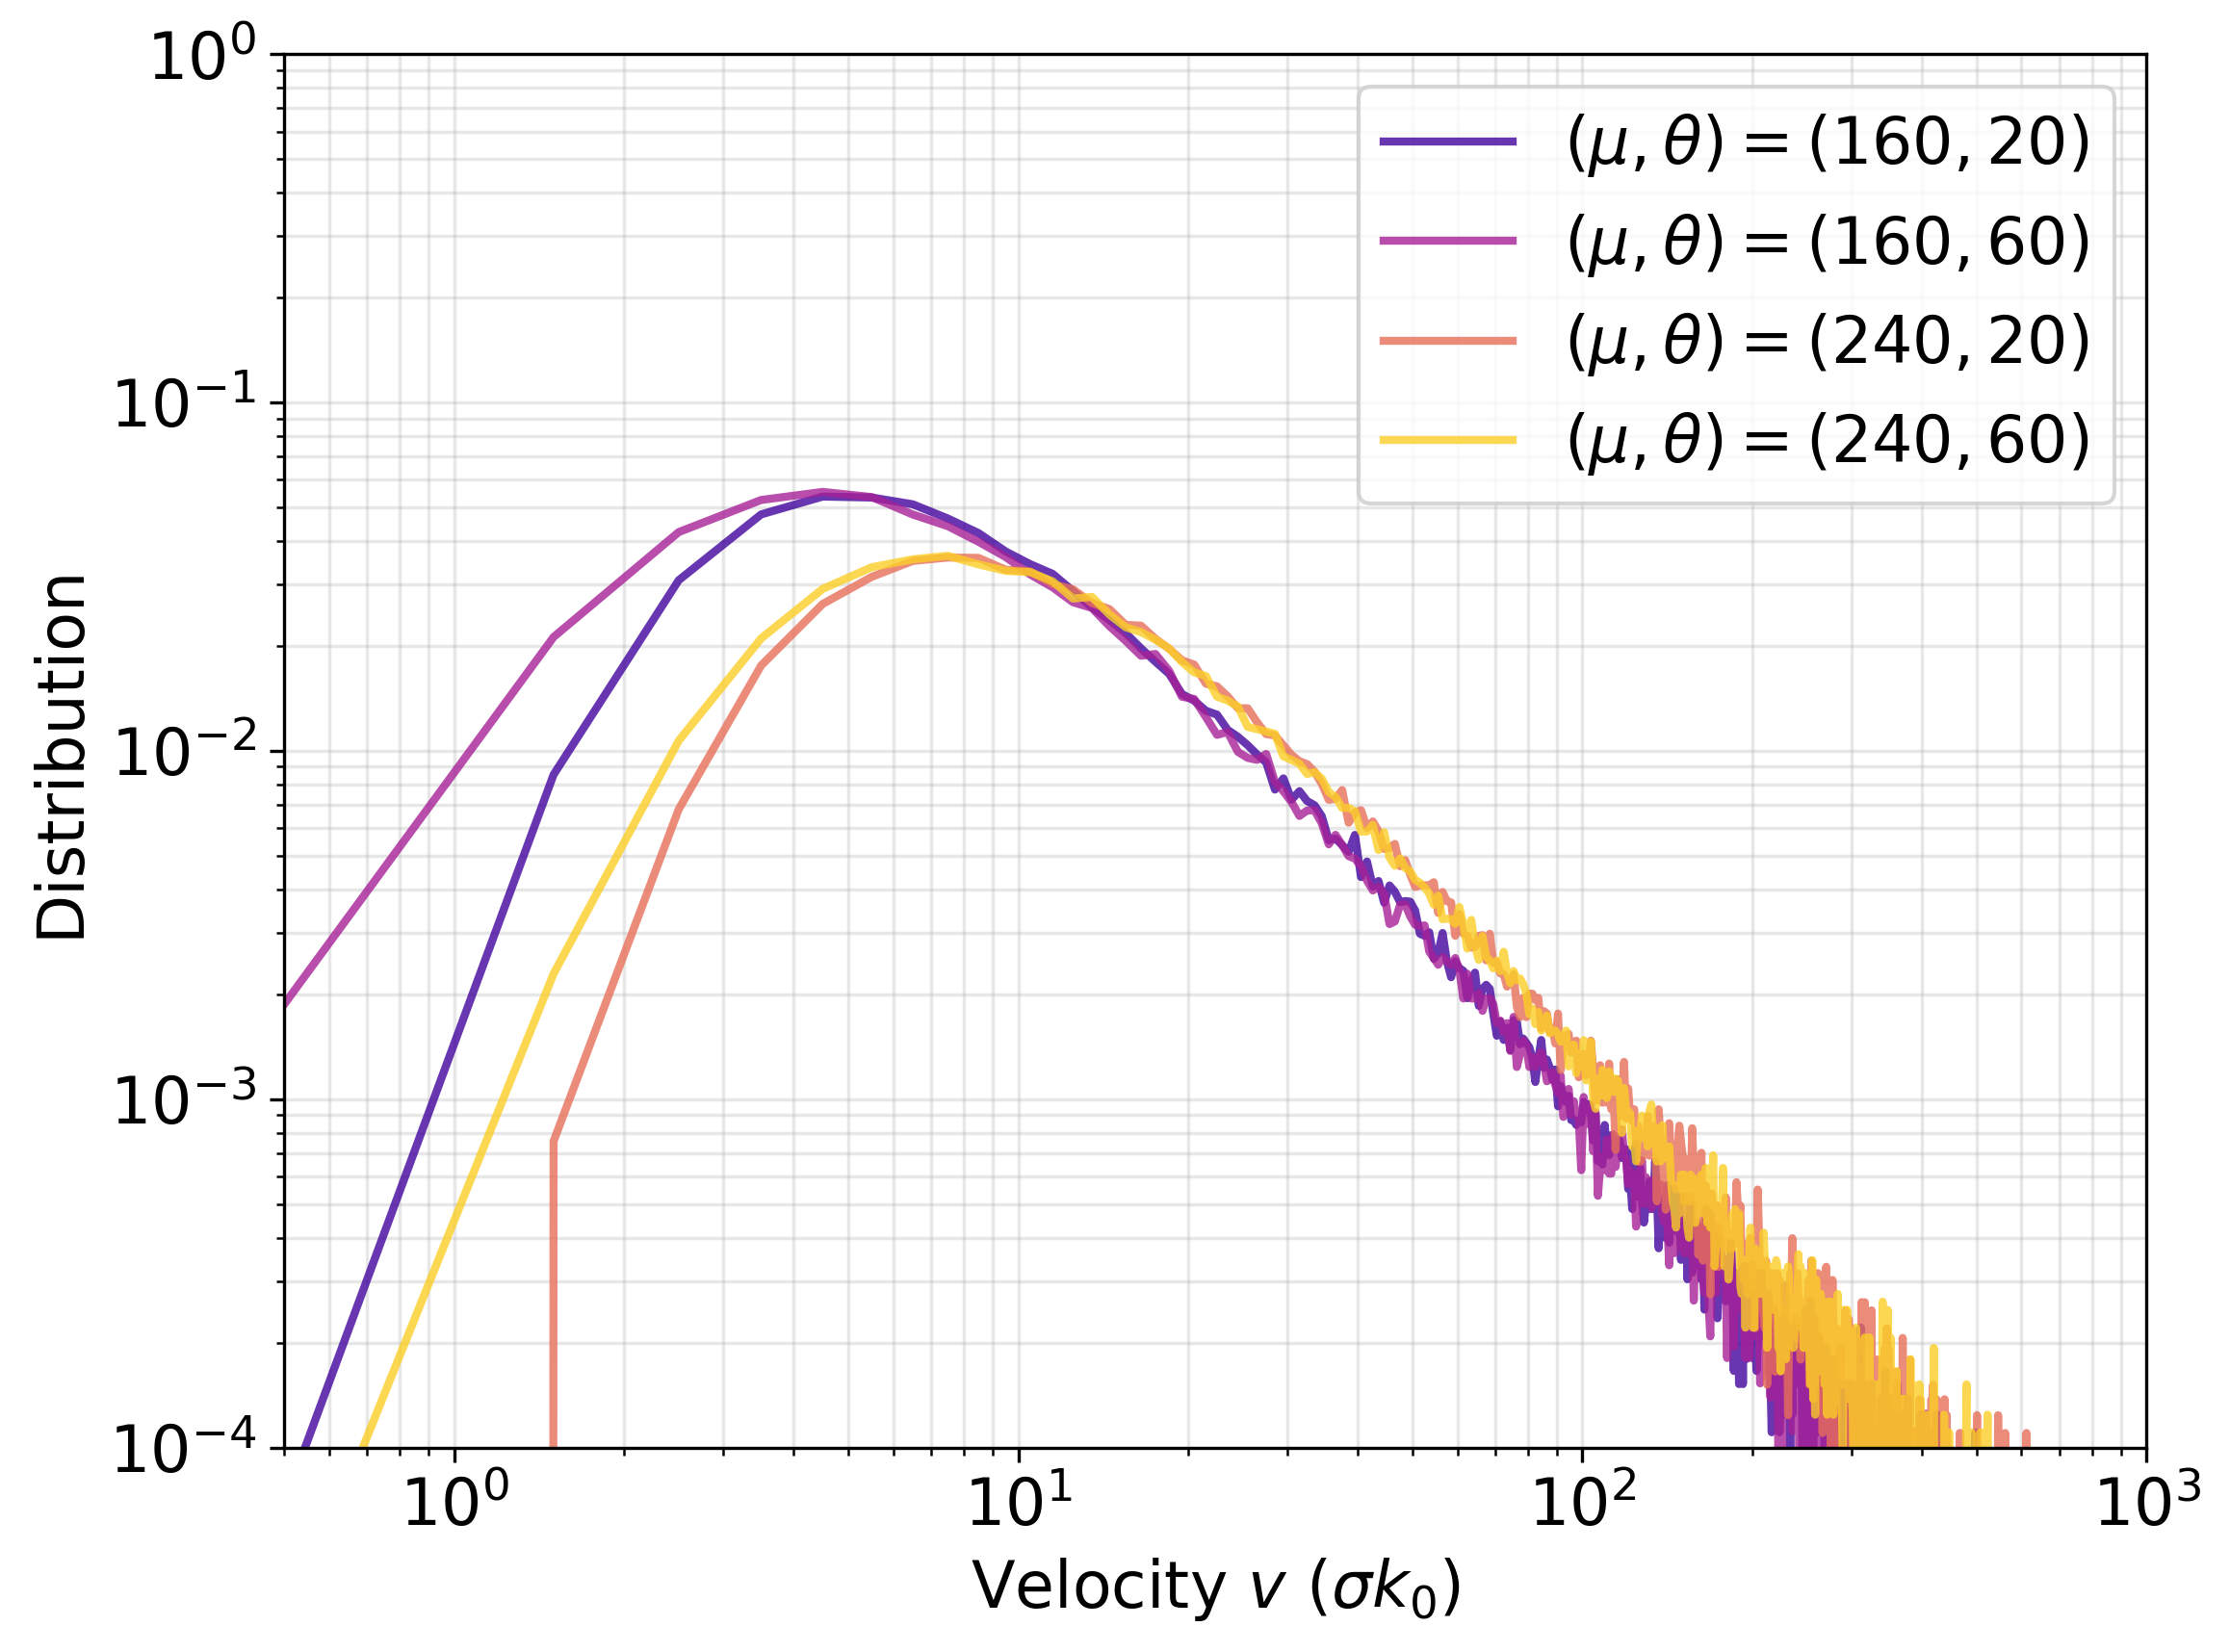

In [19]:
# ── Imports ──────────────────────────────────────────────────────────────────
from pathlib import Path
import numpy as np
import polars as pl
import matplotlib.pyplot as plt
import matplotlib.cm as cm

plt.rcParams["font.size"] = 16

# ── Load data ────────────────────────────────────────────────────────────────
root = Path(
    "/home/nicolas/Documents/Workspace/nucleo/outputs/FIGURES__PC__2026-06-18/nucleo__fig2__0"
)

paths = sorted(str(p) for p in root.glob("*/**/*.parquet"))

df_all = (
    pl.scan_parquet(paths)
    .collect()
)

# ── Filter ───────────────────────────────────────────────────────────────────
mu_values = [160, 240]
theta_values = [20, 60]

df_sel = df_all.filter(
    (pl.col("mu").is_in(mu_values)) &
    (pl.col("theta").is_in(theta_values))
)

# ── Couleurs (même cmap/style que 2.C et 2.D) ────────────────────────────────
cmap = cm.get_cmap("plasma")
color_list = cmap(np.linspace(0.1, 0.9, len(mu_values) * len(theta_values)))

# ── Plot ─────────────────────────────────────────────────────────────────────
plt.figure(figsize=(8, 6), dpi=300)

pairs = [(mu, th) for mu in mu_values for th in theta_values]

for i, (mu, theta) in enumerate(pairs):

    df_sub = df_all.filter(
        (pl.col("mu") == mu) &
        (pl.col("theta") == theta)
    )

    if len(df_sub) == 0:
        continue

    vi_points = df_sub["vi_points"][0].to_numpy()
    vi_distrib = df_sub["vi_distrib"][0].to_numpy()

    plt.plot(
        vi_points,
        vi_distrib,
        color=color_list[i],
        lw=2,
        label=fr"$(\mu,\theta)=({mu},{theta})$",
        alpha=0.80
    )

# ── Formatting ───────────────────────────────────────────────────────────────
plt.xscale("log")
plt.yscale("log")

plt.xlabel(r'Velocity $v$ ($\sigma k_0$)')
plt.ylabel("Distribution")

plt.xlim([5e-1, 1e3])
plt.ylim([1e-4, 1e0])

plt.grid(True, which="both", alpha=0.3)
plt.legend(frameon=True)

plt.tight_layout()
plt.show()


# 2.E : Heatmap $v_{mean}$ (norm\_th) avec points sélectionnés

/tmp/ipykernel_8390/3661428135.py:16: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap("plasma")


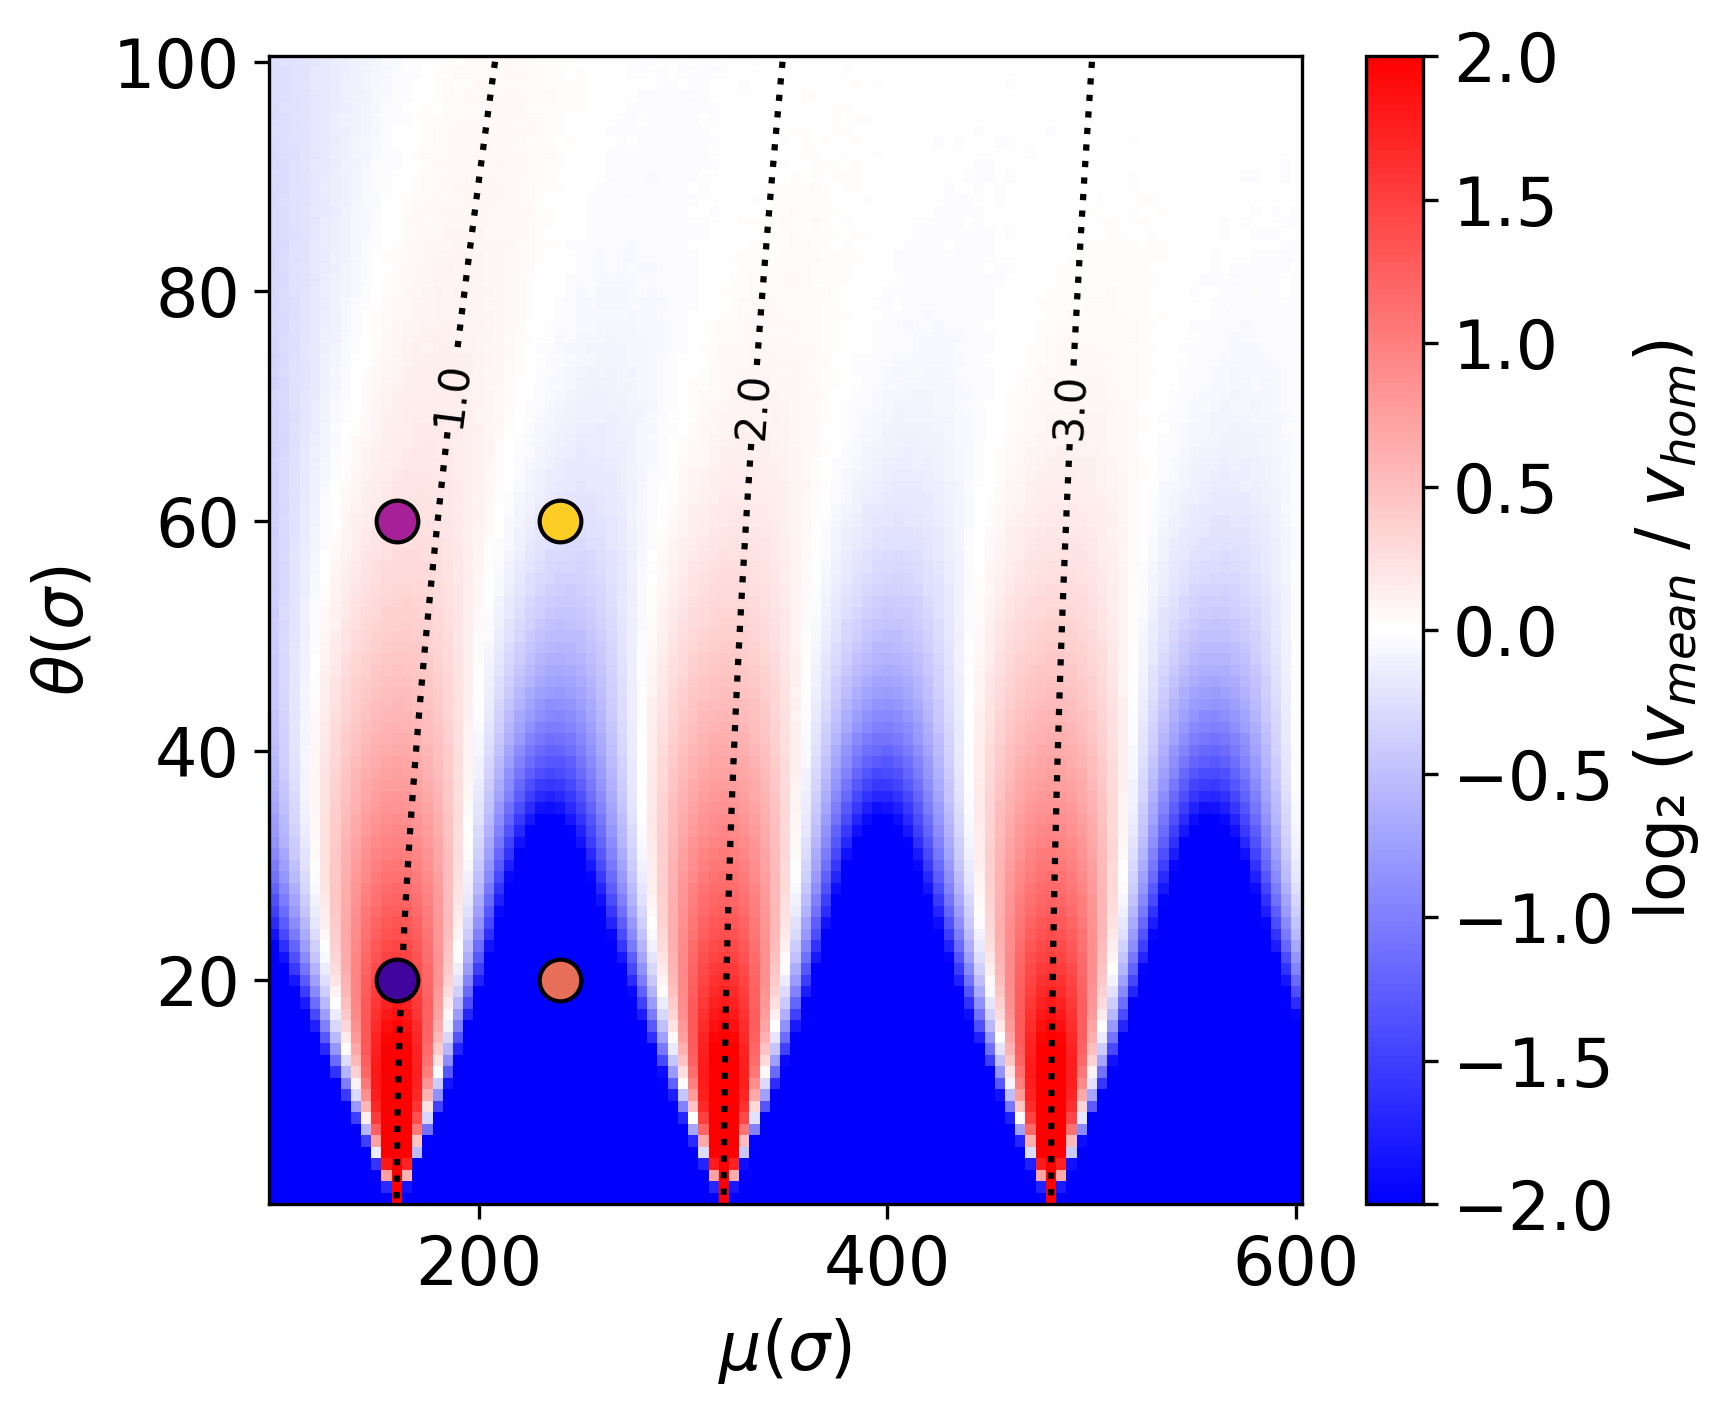

<Figure size 640x480 with 0 Axes>

In [18]:
# ── Imports ──────────────────────────────────────────────────────────────────
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm

from nucleo.io.plots_2D import plot_one_heatmap_from_df

plt.rcParams["font.size"] = 16

# ── Data ───────────────────────────────
heatmaps_df = pl.read_parquet(root / "ncl_heatmaps.parquet")
points = [(160, 20), (160, 60), (240, 20), (240, 60)]

# ── Couleurs (une couleur par point sélectionné) ─────────────────────────────
cmap = cm.get_cmap("plasma")
color_positions = np.linspace(0.1, 0.9, len(points))
color_list = [cmap(pos) for pos in color_positions]

fig, ax = plt.subplots(figsize=(6, 5), dpi=300)
plot_one_heatmap_from_df(
    heatmaps_df,
    config_idx=1,        # équivalent du `key` de l'ancien dict (premier idx = 0)
    speed_col="v_mean",
    ax=ax,
    type_of_data="norm_th",
    plot_log2=True,
    dashed_line=True,
    title=False,
)

for i, (mu_pt, theta_pt) in enumerate(points):
    ax.scatter(
        mu_pt,
        theta_pt,
        color=color_list[i],
        s=100,              # taille du point
        edgecolor="black",  # contour du point
        zorder=10           # pour être au-dessus de la heatmap
    )

plt.tight_layout()
plt.show()

plt.tight_layout()
plt.show()

# 2.D : Heatmap théorique (log2 $v_{mean}/v_{hom}$)

/tmp/ipykernel_10846/2246869004.py:20: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap("plasma")
/tmp/ipykernel_10846/2246869004.py:48: RuntimeWarning: divide by zero encountered in log2
  data_plot = np.log2(v_theo / v_flat)
/tmp/ipykernel_10846/2246869004.py:48: RuntimeWarning: invalid value encountered in log2
  data_plot = np.log2(v_theo / v_flat)
/home/nicolas/Documents/Workspace/nucleo/.venv_nucleo_3.12.3/lib/python3.12/site-packages/matplotlib/colors.py:778: RuntimeWarning: overflow encountered in multiply
  xa *= self.N


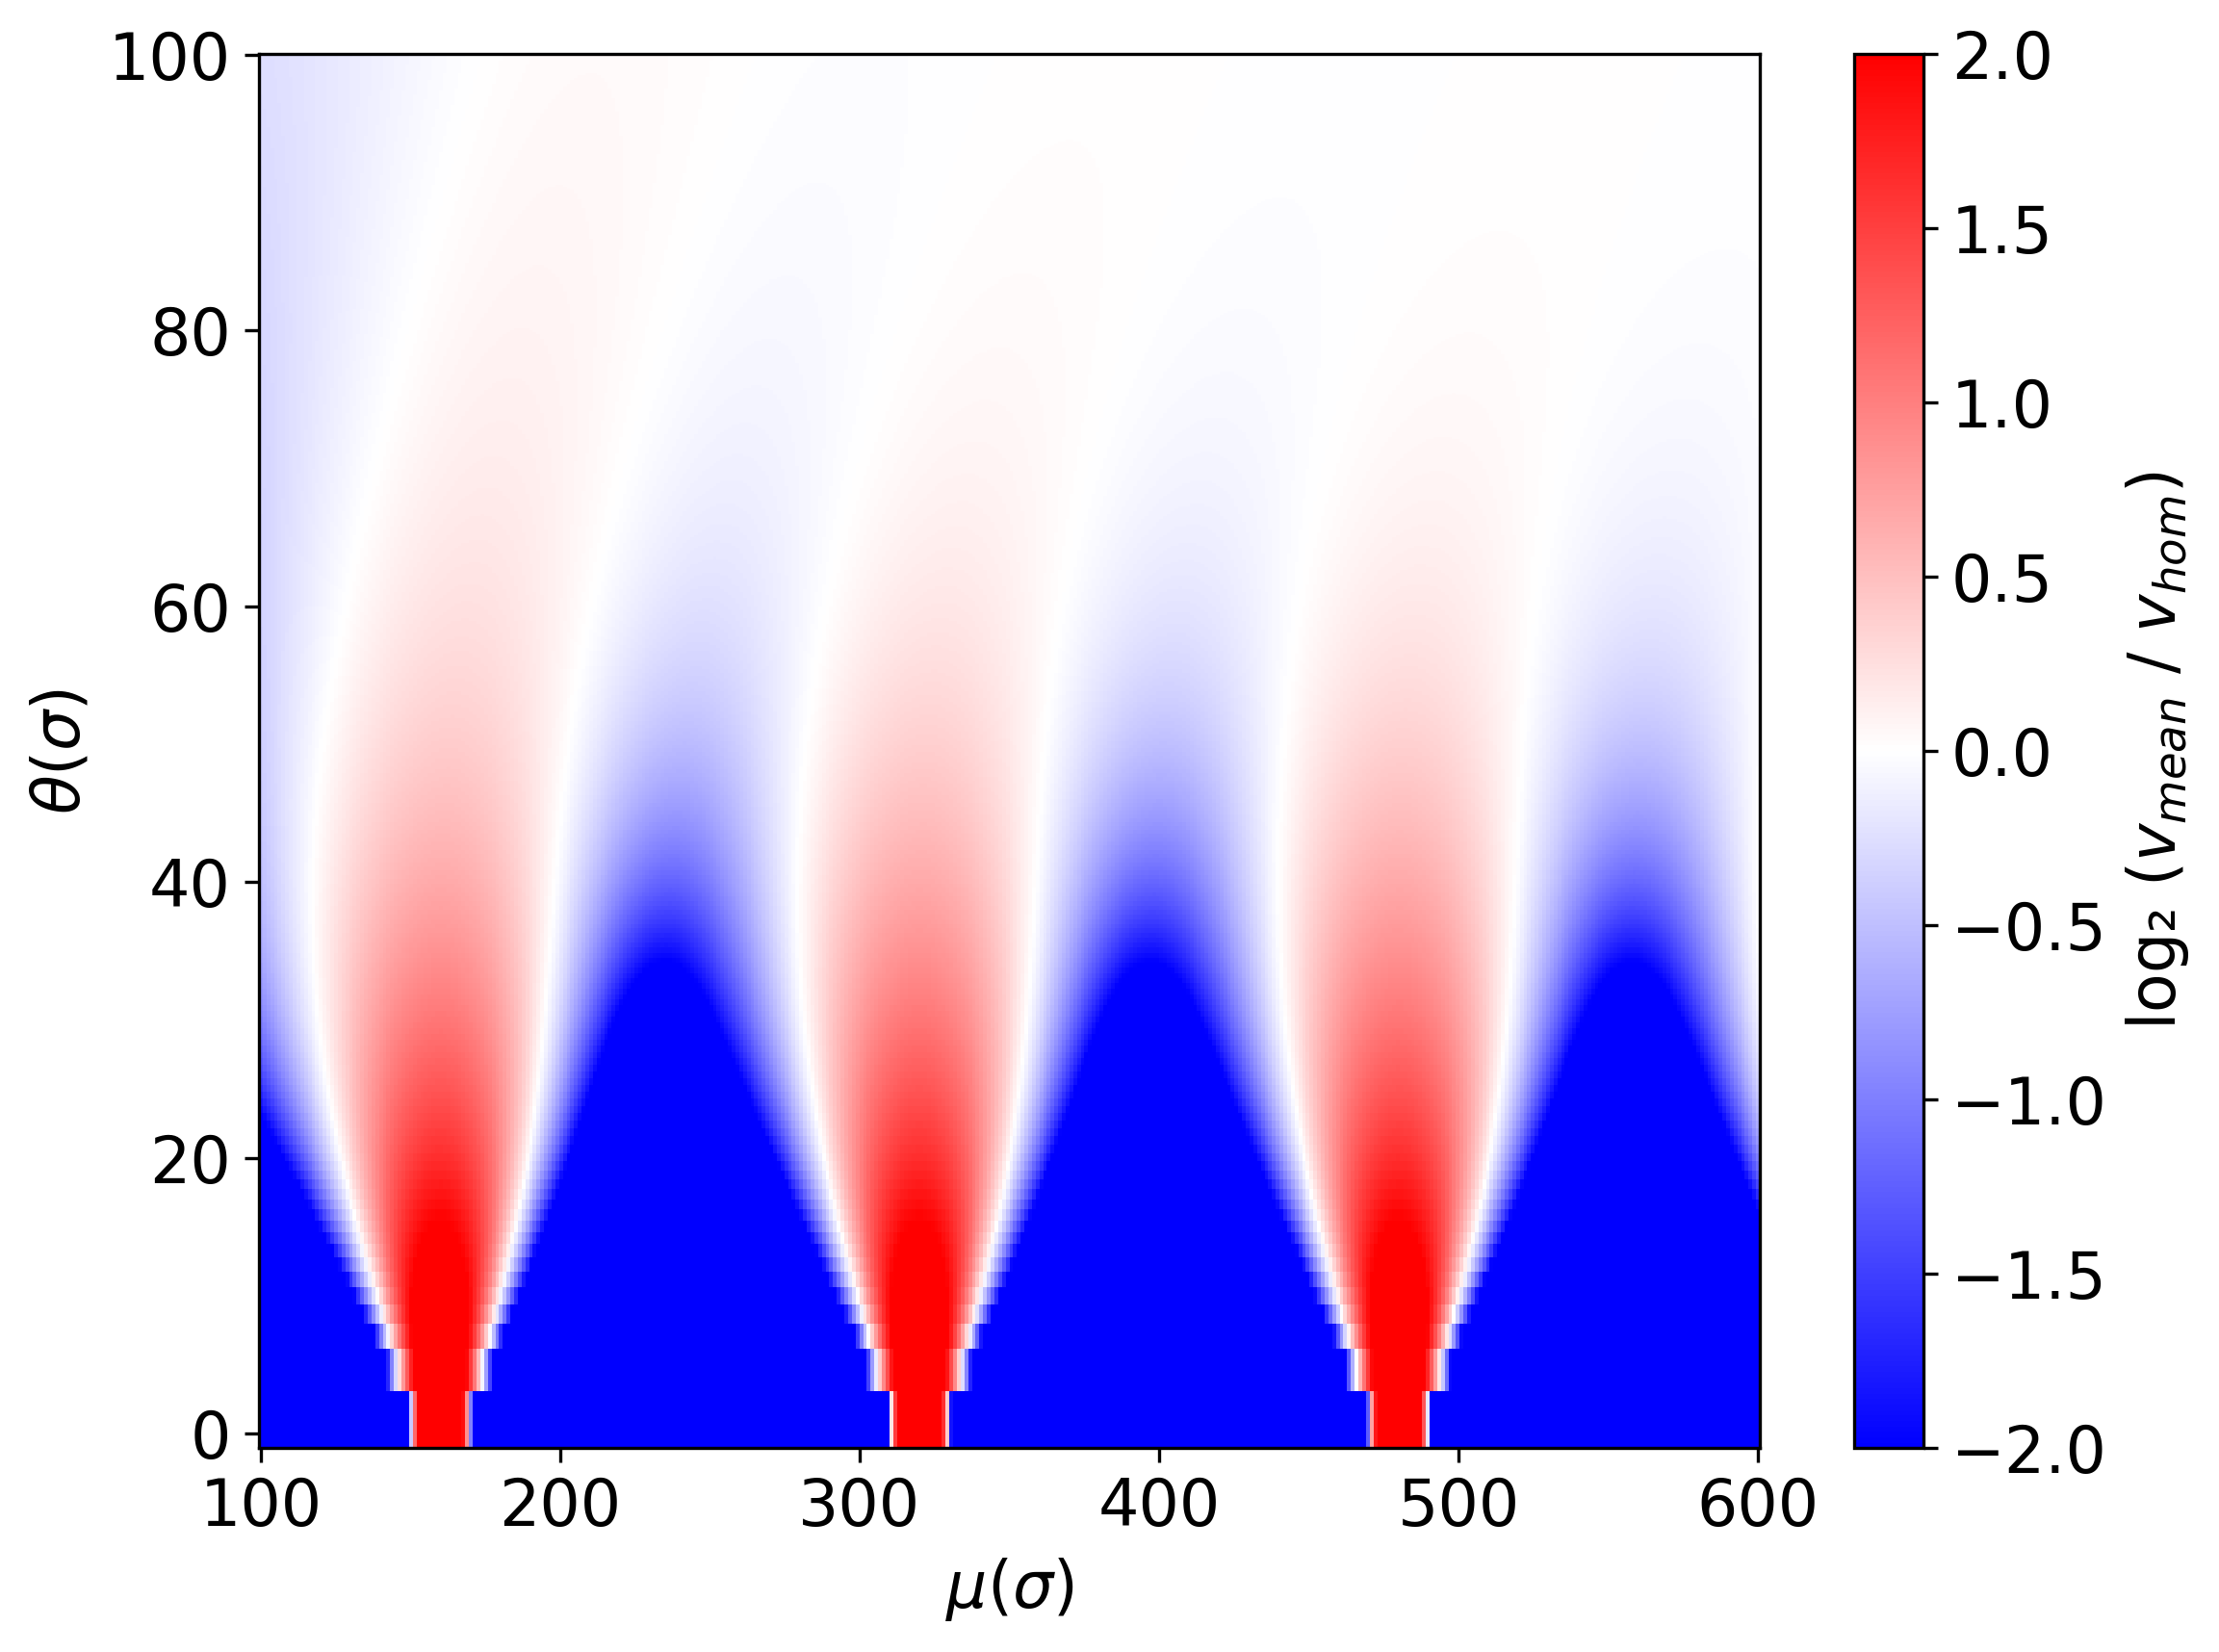

<Axes: xlabel='$\\mu(\\sigma)$', ylabel='$\\theta(\\sigma)$'>

In [5]:
# ── Options ──────────────────────────────────────────────────────────────────
to_plot = "log2"   # "raw" | "log2"
alphaf, alphao = 1, 0
l, s = 10, 150
# ─────────────────────────────────────────────────────────────────────────────

# ── Imports ──────────────────────────────────────────────────────────────────
import pickle
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm

plt.rcParams["font.size"] = 16

root = Path("/home/nicolas/Documents/Workspace/nucleo/outputs/THEORY/")

# ── Couleurs (cohérent avec la cellule 2.C : mêmes points, même cmap) ───────
points = None  # pas de points sélectionnés dans cette figure (mettre une liste de (mu, theta) si besoin)
cmap = cm.get_cmap("plasma")
color_positions = np.linspace(0.1, 0.9, 4)
color_list = [cmap(pos) for pos in color_positions]


def plot_v_theory(
    mu_vals,
    theta_vals,
    v_theo,
    to_plot="log2",        # "raw" | "log2"
    alphaf=1,
    alphao=0,
    l=10,
    s=150,
    points=None,
    color_list=None,
    ax=None,
    dpi=300,
):
    accessibility = (alphao * s + alphaf * l) / (s + l)
    v_flat = mu_vals * accessibility

    if to_plot == "raw":
        data_plot = v_theo
        vmin, vmax = None, None
        title_bar = r"$v_{mean}$"
        cmap = "viridis"
    elif to_plot == "log2":
        data_plot = np.log2(v_theo / v_flat)
        data_plot = np.nan_to_num(data_plot, nan=-2.0)
        if np.isnan(np.any(data_plot)):
            print("**")
        vmin, vmax = -2, 2
        title_bar = r"log₂ ($v_{mean}$ / $v_{hom}$)"
        cmap = "bwr"
    else:
        raise ValueError(f"to_plot must be 'raw' or 'log2', got '{to_plot}'")

    standalone = ax is None
    if standalone:
        fig, ax = plt.subplots(figsize=(8, 6), dpi=dpi)
    else:
        fig = ax.get_figure()

    im = ax.pcolormesh(
        mu_vals,
        theta_vals,
        data_plot,
        vmin=vmin,
        vmax=vmax,
        cmap=cmap,
        shading="auto",
    )
    ax.set_xlabel(r"$\mu(\sigma)$")
    ax.set_ylabel(r"$\theta(\sigma)$")

    if points:
        for i, (mu_pt, theta_pt) in enumerate(points):
            color = color_list[i] if color_list else f"C{i}"
            ax.scatter(mu_pt, theta_pt, color=color, s=100, edgecolor="black", zorder=10)

    cbar = fig.colorbar(im, ax=ax)
    cbar.set_label(title_bar)

    if standalone:
        plt.tight_layout()
        plt.show()

    return ax


# ── Main ─────────────────────────────────────────────────────────────────────
with open(root / "cesar_data.pkl", "rb") as f:
    data = pickle.load(f)

plot_v_theory(
    mu_vals=data["mu_vals"],
    theta_vals=data["sigma_vals"],
    v_theo=data["v_theo"],
    to_plot=to_plot,
    alphaf=alphaf,
    alphao=alphao,
    l=l,
    s=s,
    points=points,
    color_list=color_list,
)


In [7]:
# ── 1.1 : Python Version ─────────────────────────────────────────────────────
import sys, site
print("Python:", sys.executable)
print("User site:", site.getusersitepackages())
print("Site-packages:", site.getsitepackages() if hasattr(site, "getsitepackages") else "n/a")

# ── 1.2 : Librairies ─────────────────────────────────────────────────────────
import numpy as np
import polars as pl

from pathlib import Path
from matplotlib import pyplot as plt

from nucleo.io.reading import getting_main_file_with_verifications

plt.rcParams["font.size"] = 16


Python: /home/nicolas/Documents/Workspace/nucleo/.venv_nucleo_3.12.3/bin/python
User site: /home/nicolas/.local/lib/python3.12/site-packages
Site-packages: ['/home/nicolas/Documents/Workspace/nucleo/.venv_nucleo_3.12.3/lib/python3.12/site-packages', '/home/nicolas/Documents/Workspace/nucleo/.venv_nucleo_3.12.3/local/lib/python3.12/dist-packages', '/home/nicolas/Documents/Workspace/nucleo/.venv_nucleo_3.12.3/lib/python3/dist-packages', '/home/nicolas/Documents/Workspace/nucleo/.venv_nucleo_3.12.3/lib/python3.12/dist-packages']


In [9]:
# ── Imports (bloc indépendant) ───────────────────────────────────────────────
import numpy as np
import polars as pl
from pathlib import Path

from nucleo.io.reading import getting_main_file_with_verifications

# ── 2.1 : Functions ──────────────────────────────────────────────────────────

# Datas
def data_one_scen(df: pl.DataFrame, scen: dict) -> pl.DataFrame:
    return df.filter(
        (pl.col("land") == scen["land"])
        & (pl.col("s") == scen["s"])
        & (pl.col("l") == scen["l"])
        & (pl.col("bpmin") == scen["bpmin"])
    )


# Cuts
def cut_1_mu(df: pl.DataFrame, scen: dict, mu: int) -> pl.DataFrame:
    return df.filter(
        (pl.col("land") == scen["land"])
        & (pl.col("s") == scen["s"])
        & (pl.col("l") == scen["l"])
        & (pl.col("bpmin") == scen["bpmin"])
        & (pl.col("mu") == mu)
    )

def cut_1_theta(df: pl.DataFrame, scen: dict, theta: int) -> pl.DataFrame:
    return df.filter(
        (pl.col("land") == scen["land"])
        & (pl.col("s") == scen["s"])
        & (pl.col("l") == scen["l"])
        & (pl.col("bpmin") == scen["bpmin"])
        & (pl.col("theta") == theta)
    )

def cut_1_l(df: pl.DataFrame, scen: dict, mu: int, theta: int) -> pl.DataFrame:
    return df.filter(
        (pl.col("land") == scen["land"])
        & (pl.col("s") == scen["s"])
        & (pl.col("bpmin") == scen["bpmin"])
        & (pl.col("mu") == mu)
        & (pl.col("theta") == theta)
    )


# ── 2.2 : Getting datas ──────────────────────────────────────────────────────

# Root
root = Path.home() / "Documents" / "Workspace" / "nucleo" / "outputs" / "NUCLEO__PSMN__2026-06-19"

# Reading
path_datas = root / "ncl_output.parquet"
df_all = pl.read_parquet(path_datas)

# Loading + Filtering
df_secured = getting_main_file_with_verifications(df_all)

# Ordering
df_sorted = df_secured.sort(
        by=["s", "land", "bpmin", "l"],
        descending=[False, False, False, False]
    )
# print(df_sorted)

# ── 2.3 : Reading Scenarios ──────────────────────────────────────────────────

# Reading
path_scenario = root / "scenarios.json"
df_all_scen = pl.read_json(path_scenario)

# Ordering
df_all_scen_ordered = df_all_scen.sort(
        by=["s", "land", "bpmin", "l"],
        descending=[False, False, False, False]
    )
# print(df_all_scen_ordered)

# ── 2.4 : Prints ─────────────────────────────────────────────────────────────

print("All scenarios:\n", df_all_scen_ordered)

df_scen_nucleo = df_all_scen_ordered[0, 1, 3]
# print("Nucleo scenarios:\n", df_scen_nucleo)

df_scen_linker = df_all_scen_ordered[1, 4:9]
# print("Linker scenarios:\n", df_scen_linker)

df_scen_bpmin = df_all_scen_ordered[9:12]
# print("Bpmin scenarios:\n", df_scen_bpmin)


All scenarios:
 shape: (20, 4)
┌─────┬─────┬───────┬──────────┐
│ s   ┆ l   ┆ bpmin ┆ land     │
│ --- ┆ --- ┆ ---   ┆ ---      │
│ i64 ┆ i64 ┆ i64   ┆ str      │
╞═════╪═════╪═══════╪══════════╡
│ 150 ┆ 10  ┆ 0     ┆ homogen  │
│ 150 ┆ 5   ┆ 0     ┆ periodic │
│ 150 ┆ 10  ┆ 0     ┆ periodic │
│ 150 ┆ 15  ┆ 0     ┆ periodic │
│ 150 ┆ 20  ┆ 0     ┆ periodic │
│ …   ┆ …   ┆ …     ┆ …        │
│ 150 ┆ 100 ┆ 0     ┆ random   │
│ 150 ┆ 150 ┆ 0     ┆ random   │
│ 150 ┆ 10  ┆ 5     ┆ random   │
│ 150 ┆ 10  ┆ 10    ┆ random   │
│ 150 ┆ 10  ┆ 15    ┆ random   │
└─────┴─────┴───────┴──────────┘


## FIG 2.C.1 : Cuts of heatmaps — valeurs de µ

Working on :
 shape: (1, 4)
┌─────┬─────┬───────┬──────────┐
│ s   ┆ l   ┆ bpmin ┆ land     │
│ --- ┆ --- ┆ ---   ┆ ---      │
│ i64 ┆ i64 ┆ i64   ┆ str      │
╞═════╪═════╪═══════╪══════════╡
│ 150 ┆ 5   ┆ 0     ┆ periodic │
└─────┴─────┴───────┴──────────┘
shape: (10_100, 27)
┌──────────┬─────┬─────┬───────┬───┬──────────┬─────────────┬────────────┬───────┐
│ land     ┆ s   ┆ l   ┆ bpmin ┆ … ┆ wf_std   ┆ vi_mean     ┆ vi_med     ┆ vi_mp │
│ ---      ┆ --- ┆ --- ┆ ---   ┆   ┆ ---      ┆ ---         ┆ ---        ┆ ---   │
│ str      ┆ i64 ┆ i64 ┆ i64   ┆   ┆ f64      ┆ f64         ┆ f64        ┆ f64   │
╞══════════╪═════╪═════╪═══════╪═══╪══════════╪═════════════╪════════════╪═══════╡
│ periodic ┆ 150 ┆ 5   ┆ 0     ┆ … ┆ 0.010574 ┆ 149.555095  ┆ 18.821367  ┆ 7.5   │
│ periodic ┆ 150 ┆ 5   ┆ 0     ┆ … ┆ 0.002262 ┆ 3408.121081 ┆ 310.42157  ┆ 105.5 │
│ periodic ┆ 150 ┆ 5   ┆ 0     ┆ … ┆ 0.003755 ┆ 2198.808688 ┆ 246.513153 ┆ 95.5  │
│ periodic ┆ 150 ┆ 5   ┆ 0     ┆ … ┆ 0.003927 ┆ 1567.2333

/tmp/ipykernel_10846/3871854497.py:132: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


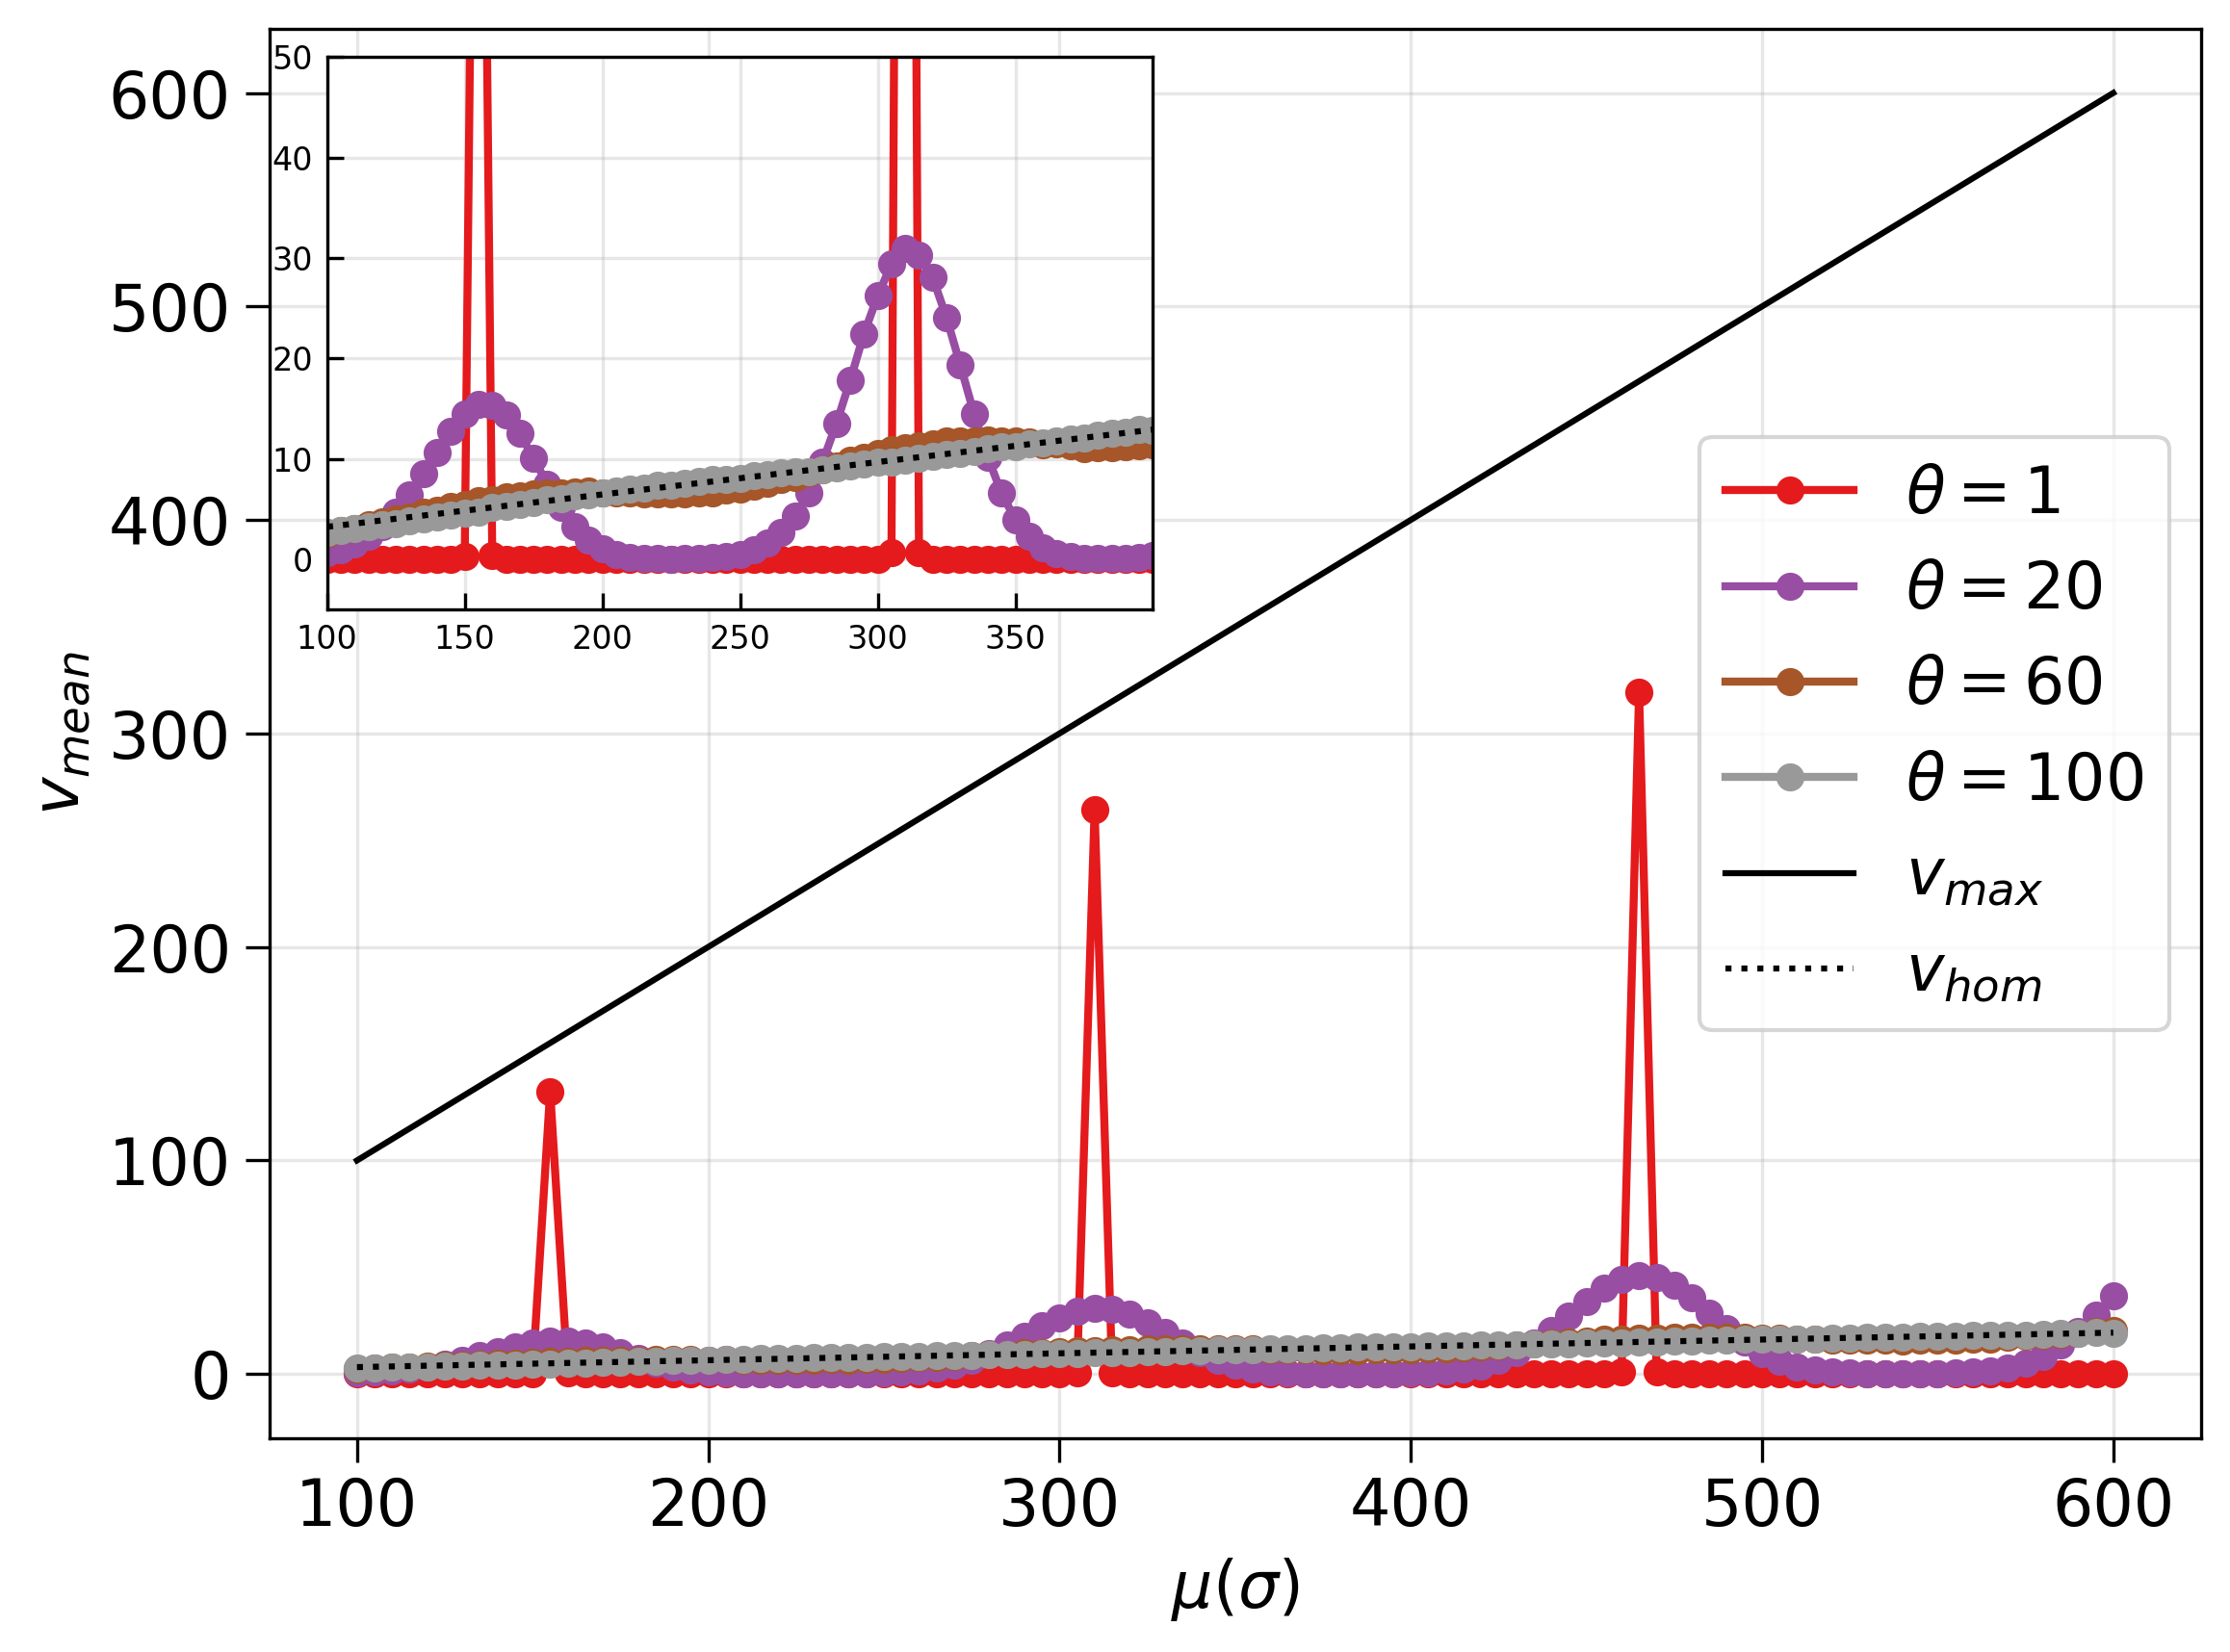

In [10]:
# ── Imports ──────────────────────────────────────────────────────────────────
import numpy as np
import polars as pl
import matplotlib.pyplot as plt
from matplotlib import cm
from mpl_toolkits.axes_grid1.inset_locator import inset_axes, mark_inset

plt.rcParams["font.size"] = 16
fontsize = 16

# ── Sélection du scénario ────────────────────────────────────────────────────
df_scen_work = df_scen_nucleo[1]
print("Working on :\n", df_scen_work)

df_work = df_sorted.filter(
    (df_sorted["land"] == df_scen_work["land"]) &
    (df_sorted["s"] == df_scen_work["s"]) &
    (df_sorted["l"] == df_scen_work["l"]) &
    (df_sorted["bpmin"] == df_scen_work["bpmin"])
)
print(df_work)

mus = np.unique(df_work["mu"].to_numpy())
thetas = np.unique(df_work["theta"].to_numpy())
print(mus, thetas)

thetas = np.array([1, 20, 60, 100])
mus = np.array([160, 200, 240])

# ── Couleurs (cohérentes avec les cellules suivantes de cette section) ──────
cmap_1 = plt.get_cmap("Set1")
cmap_2 = plt.get_cmap("Set1")
colors_1 = [cmap_1(i / (len(thetas) - 1)) for i in range(len(thetas))]
colors_2 = [cmap_2(i / (len(mus) - 1)) for i in range(len(mus))]

# ── Data pour la coupe en mu ─────────────────────────────────────────────────
df_all_plot = df_work.filter(
    pl.col("theta").is_in(thetas)
)

title = df_all_plot["land"][0]

mu = df_all_plot["mu"].to_numpy()
alphaf = df_all_plot["alphaf"].to_numpy()
alphao = df_all_plot["alphao"].to_numpy()
l = df_all_plot["l"].to_numpy()
s = df_all_plot["s"].to_numpy()

v_max = np.unique(mu)
alpha_mean = ((alphaf * l + alphao * s) / (l + s))
v_hom = np.unique(mu * alpha_mean)

if title == "nt_random":
    title = "Random"

# ── Plot ─────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 6), dpi=300)

ax.tick_params(
    axis="both",
    which="both",
    direction="out",
    labelsize=16,
    length=6
)

for (col, theta) in zip(colors_1, thetas):
    df_one_plot = (
        df_all_plot
        .filter(pl.col("theta") == theta)
        .sort("mu", descending=False)
    )

    mu_plot = df_one_plot["mu"].to_numpy()
    v_mean = df_one_plot["v_mean"].to_numpy()

    ax.plot(mu_plot, v_mean, marker="o", color=col, lw=2, label=f"$\\theta={theta}$")

ax.plot(mu_plot, v_max, label="$v_{max}$", color="black", ls="-")
ax.plot(mu_plot, v_hom, label="$v_{hom}$", color="black", ls=":")

ax.set_xlabel("$\\mu(\\sigma)$", fontsize=fontsize)
ax.set_ylabel("$v_{mean}$", fontsize=fontsize)
ax.grid(True, alpha=0.3)
ax.legend(loc="center right", ncols=1)

# ── Inset zoom ───────────────────────────────────────────────────────────────
axins = inset_axes(
    ax,
    width="45%",
    height="40%",
    loc="upper left",
    bbox_to_anchor=(0.03, 0.0, 0.95, 0.98),
    bbox_transform=ax.transAxes,
    borderpad=0
)

for (col, theta) in zip(colors_1, thetas):
    df_one_plot = (
        df_all_plot
        .filter(pl.col("theta") == theta)
        .sort("mu", descending=False)
    )

    mu_plot = df_one_plot["mu"].to_numpy()
    v_mean = df_one_plot["v_mean"].to_numpy()

    axins.plot(mu_plot, v_mean, marker="o", color=col, lw=2)

axins.plot(mu_plot, v_max, color="black", ls="-")
axins.plot(mu_plot, v_hom, color="black", ls=":")

axins.set_xticks([100, 150, 200, 250, 300, 350])
axins.set_yticks([0, 10, 20, 30, 40, 50])

axins.tick_params(
    axis="both",
    which="both",
    direction="in",
    labelsize=8,
    length=4,
    width=0.8
)

axins.set_xlim(100, 400)
axins.set_ylim(-5, 50)
axins.grid(True, alpha=0.3)

# Relier la zone zoomée
# mark_inset(ax, axins, loc1=2, loc2=4, fc="none", ec="0.5")

plt.tight_layout()
plt.show()


## FIG 2.C.2 : Cuts of heatmaps — valeurs de θ

/tmp/ipykernel_10846/951402982.py:139: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


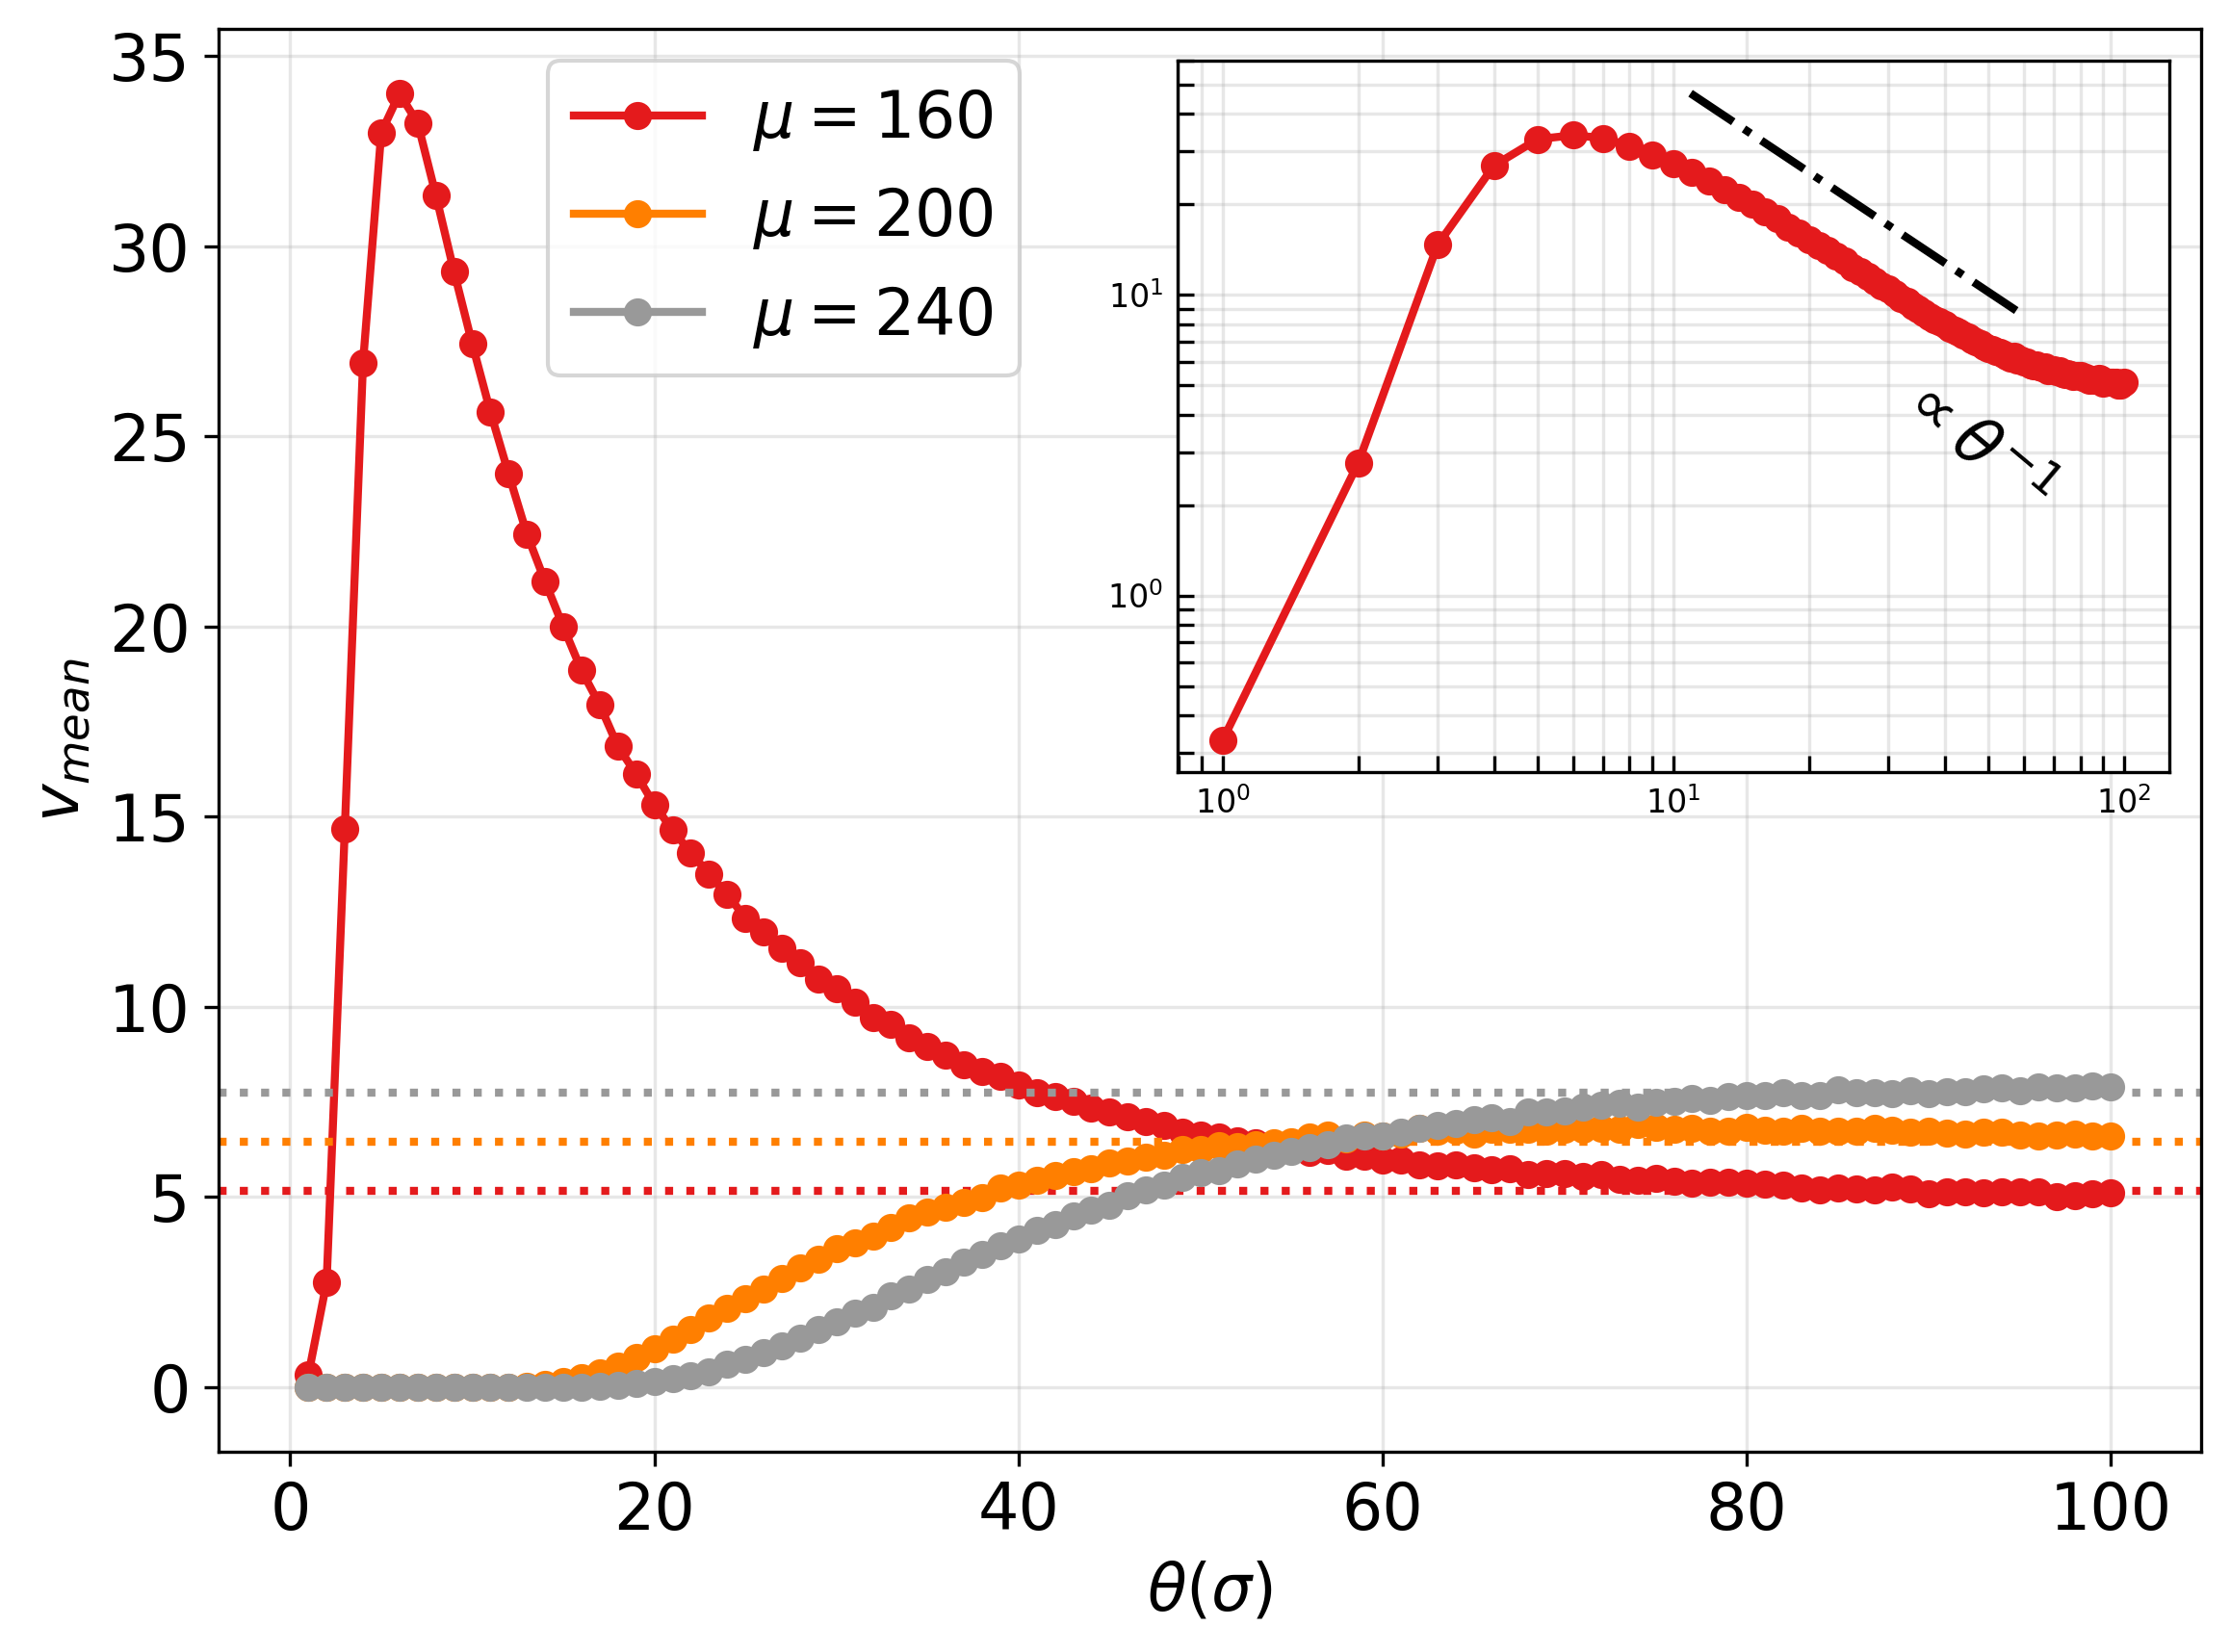

In [11]:
# ── Imports ──────────────────────────────────────────────────────────────────
import numpy as np
import polars as pl
import matplotlib.pyplot as plt
from matplotlib import cm
from mpl_toolkits.axes_grid1.inset_locator import inset_axes, mark_inset

plt.rcParams["font.size"] = 16

# ── Sélection du scénario (même que FIG 2.C.1) ───────────────────────────────
df_scen_work = df_scen_nucleo[1]

df_work = df_sorted.filter(
    (df_sorted["land"] == df_scen_work["land"]) &
    (df_sorted["s"] == df_scen_work["s"]) &
    (df_sorted["l"] == df_scen_work["l"]) &
    (df_sorted["bpmin"] == df_scen_work["bpmin"])
)

mus = np.array([160, 200, 240])

# ── Couleurs (cohérentes avec FIG 2.C.1) ─────────────────────────────────────
cmap_2 = plt.get_cmap("Set1")
colors_2 = [cmap_2(i / (len(mus) - 1)) for i in range(len(mus))]

df_all_plot = df_work.filter(
    pl.col("mu").is_in(mus)
)

title = df_all_plot["land"][0]
if title == "nt_random":
    title = "Random"

alphaf = df_all_plot["alphaf"].to_numpy()
alphao = df_all_plot["alphao"].to_numpy()
l = df_all_plot["l"].to_numpy()
s = df_all_plot["s"].to_numpy()
alpha_mean = ((alphaf * l + alphao * s) / (l + s))

# ── Figure ───────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 6), dpi=300)

for mu, col in zip(mus, colors_2):

    df_one_plot = (
        df_all_plot
        .filter(pl.col("mu") == mu)
        .sort("theta")
    )

    theta = df_one_plot["theta"].to_numpy()
    v_mean = df_one_plot["v_mean"].to_numpy()

    # courbe principale
    ax.plot(
        theta, v_mean,
        marker="o", lw=2,
        color=col,
        label=rf"$\mu={mu}$"
    )

    # ligne horizontale associée
    ax.axhline(
        y=alpha_mean[0] * mu,
        ls=":", lw=2,
        color=col
    )

# ── Labels ───────────────────────────────────────────────────────────────────
ax.set_xlabel(r"$\theta(\sigma)$")
ax.set_ylabel("$v_{mean}$")
ax.grid(True, alpha=0.3, which="both")
ax.legend(
    loc="upper left",
    bbox_to_anchor=(0.15, 1.0)
)

# ── Inset ────────────────────────────────────────────────────────────────────
axins = inset_axes(ax, width="50%", height="50%", loc="upper right")

# données de la courbe de référence (mu=160)
mu_ref = 160
col_ref = colors_2[0]

df_ref = (
    df_all_plot
    .filter(pl.col("mu") == mu_ref)
    .sort("theta")
)

theta = df_ref["theta"].to_numpy()
v_mean = df_ref["v_mean"].to_numpy()

# courbe réelle
axins.loglog(
    theta,
    v_mean,
    "o-",
    color=col_ref,
    lw=2,
    label="Simulation"
)

# loi d'échelle theta^{-1}
A = v_mean[-1] * theta[-1]      # normalisation

theta_fit = np.linspace(theta.min(), theta.max(), 500)
v_fit = A * theta_fit**(-1)

axins.loglog(
    theta_fit[50:300],
    v_fit[50:300],
    "-.k",
    lw=2
)

axins.text(
    0.93, 0.65,                         # (x,y) en coordonnées d'axe
    r"$\propto \theta^{-1}$",
    transform=ax.transAxes,
    fontsize=16,
    color="black",
    ha="right",
    va="bottom",
    rotation=-40
)

axins.grid(True, which="both", alpha=0.3)

axins.tick_params(
    axis="both",
    which="both",
    direction="in",
    labelsize=8,
    length=4,
    width=0.8
)

plt.tight_layout()
plt.show()


# .